# **課程：社群媒體分析 MIS_581**

授課教授：黃三益老師

組別：Group_9

專案：對Reddit 社群對於「美國與伊朗戰爭（US Iran war）」討論版進行情緒分析

組員：

楊凱傑 N134020003、陳信宏 N134020006、郭羽庭 N134320008、

黎書宏 N134020009、鍾宛樺 N134320013、盧柔樺 N134320016

# 1.主題介紹

## 1.1 資料說明

本研究利用 Python 進行自動化資料爬取，針對 Reddit 社群平台上的討論進行深度分析。

* **資料來源**：使用 Pullpush 提供的 Reddit 搜尋 API。
* **開發工具**：`requests` (網路請求)、`pandas` (資料處理與分析)。
* **搜尋關鍵字**：
    * `US Iran war` (美伊戰爭)
    * `Iran attack` (伊朗攻擊)
    * `Iran nuclear` (伊朗核武)
    * `Iran missile` (伊朗飛彈)
    * `Iran sanction` (伊朗制裁)
* **時間範圍**：`2025-03` 至 `2025-05` (或依實際抓取區間填寫)
* **資料量**：共計 1199 篇文章

## 1.2 分析動機及目的

**背景脈絡**

目前局勢顯示，**2026年美伊衝突已進入高度緊張階段**。自 2026 年 2 月 28 日衝突爆發以來，局勢由最初的精確打擊逐漸演變為影響整個中東地區，並波及全球經濟的持續性戰事。此次衝突並非突發，而是長期外交失敗與軍事對峙累積後的結果。

**研究動機**

目前局勢顯示，2026年美伊衝突已進入高度緊張階段。衝突由最初的精確打擊逐漸演變為影響整個中東地區，並波及全球經濟的持續性戰事。此次衝突並非突發，而是長期外交失敗與軍事對峙累積後的結果。本組研究動機在於探索並分析 Reddit 社群對於「美國與伊朗戰爭（US–Iran war）」相關議題的討論與觀點，主要可分為兩個核心面向：

1.關鍵字與議題分析 (Keyword Analysis)
透過文本清理與資料處理，生成文字雲（Word Cloud）視覺化圖表，以辨識社群關注的焦點：
* **核心主體**：如美國 (US)、以色列 (Israel) 等國家角色。
* **政治影響**：如川普 (Trump) 等政治人物在衝突中的影響力。
* **軍事情報**：如摩薩德 (Mossad) 及相關軍事動態的討論熱度。

2.情緒分析 (Sentiment Analysis)
利用自然語言處理工具對評論進行自動化分類：
* **分類維度**：正面 (Positive)、負面 (Negative) 與中性 (Neutral)。
* **分析目標**：透過圖表量化社群對美伊戰爭的整體態度，觀察在戰爭升級過程中，公眾輿論的情緒傾向與變化。

# 2.資料清理與文本資料處理

對擷取到的 Reddit 評論文本進行清理，包括移除URL、特殊字元、數字，並進行斷詞處理及移除停用詞，以便後續的文字雲生成和情緒分析。


##2.1資料擷取


In [ ]:
import requests
import pandas as pd
import time
import re
import html
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

PULLPUSH_API_ENDPOINT = 'https://api.pullpush.io/reddit/search/submission/'

# ── 設定關鍵詞 ────────────────────────────────────────────────
keywords = [
    'US Iran war',
    'Iran attack',
    'Iran nuclear',
    'Iran missile',
    'Iran sanction'
]
PAGES_PER_KEYWORD = 5   # 每個關鍵詞最多爬幾頁（每頁 100 筆）
# ─────────────────────────────────────────────────────────────

all_posts = []

for keyword in keywords:
    before = None
    print(f"\n[Keyword] '{keyword}'")
    for page in range(PAGES_PER_KEYWORD):
        params = {
            'q': keyword,
            'size': 100,
            'sort': 'desc',
            'sort_type': 'created_utc',
        }
        if before:
            params['before'] = before

        try:
            r = requests.get(PULLPUSH_API_ENDPOINT, params=params, timeout=15)
            r.raise_for_status()
            data = r.json().get('data', [])
            if not data:
                print(f"  Page {page+1}: no more data")
                break
            all_posts.extend(data)
            before = data[-1]['created_utc']
            print(f"  Page {page+1}: +{len(data)} posts (total so far: {len(all_posts)})")
            time.sleep(1)
        except Exception as e:
            print(f"  Page {page+1}: Error — {e}")
            break

# ── Step 1: 建立原始 DataFrame ────────────────────────────────
df_raw = pd.DataFrame(all_posts).drop_duplicates(subset='id') if all_posts else pd.DataFrame()


[Keyword] 'US Iran war'
  Page 1: +100 posts (total so far: 100)
  Page 2: +100 posts (total so far: 200)
  Page 3: +100 posts (total so far: 300)
  Page 4: +100 posts (total so far: 400)
  Page 5: +100 posts (total so far: 500)

[Keyword] 'Iran attack'
  Page 1: +100 posts (total so far: 600)
  Page 2: +100 posts (total so far: 700)
  Page 3: +100 posts (total so far: 800)
  Page 4: +100 posts (total so far: 900)
  Page 5: +100 posts (total so far: 1000)

[Keyword] 'Iran nuclear'
  Page 1: +100 posts (total so far: 1100)
  Page 2: +100 posts (total so far: 1200)
  Page 3: +100 posts (total so far: 1300)
  Page 4: +100 posts (total so far: 1400)
  Page 5: +100 posts (total so far: 1500)

[Keyword] 'Iran missile'
  Page 1: +100 posts (total so far: 1600)
  Page 2: +100 posts (total so far: 1700)
  Page 3: +100 posts (total so far: 1800)
  Page 4: +100 posts (total so far: 1900)
  Page 5: +100 posts (total so far: 2000)

[Keyword] 'Iran sanction'
  Page 1: +100 posts (total so far: 2100

##2.2 清理與處理文本資料


In [ ]:
# ── Step 2: 清理 ──────────────────────────────────────────────
if not df_raw.empty:
    clear_df = df_raw[['title', 'created_utc', 'url', 'selftext']].copy()
    clear_df.columns = ['title', 'date', 'link', 'content']

    # 日期格式
    clear_df['date'] = pd.to_datetime(clear_df['date'], unit='s').dt.strftime('%Y-%m-%d')

    # 移除有空值的行
    clear_df.dropna(axis=0, how='any', inplace=True)

    # 移除 content 為空的行
    clear_df.dropna(subset=['content'], axis=0, how='any', inplace=True)

    # 移除 content 為 [deleted] / [removed] 的行
    clear_df = clear_df[~clear_df['content'].isin(['[deleted]', '[removed]', ''])]

    def clean_text(text):
        text = str(text)                                    # 強制轉字串，避免 NaN 報錯
        text = html.unescape(text)                          # 還原 &gt; &amp; 等 HTML 實體
        text = re.sub(r'http\S+|www\S+', '', text)         # 移除網址

        # ── 轉小寫前先保護專有名詞（避免 US → us「我們」）──
        text = re.sub(r'\bThe US\b',        'usa', text, flags=re.IGNORECASE)
        text = re.sub(r'\bthe U.S.',        'usa', text, flags=re.IGNORECASE)
        text = re.sub(r'\bu.s.',        'usa', text, flags=re.IGNORECASE)
        text = re.sub(r'\bUS\b',            'usa', text, flags=re.IGNORECASE)
        text = re.sub(r'\bU\.S\.\b',        'usa', text, flags=re.IGNORECASE)
        text = re.sub(r'\bAmerica\b',       'usa', text, flags=re.IGNORECASE)
        text = re.sub(r'\bIran\b',          'iran',          text, flags=re.IGNORECASE)
        text = re.sub(r'\bIranian\b',       'iranian',       text, flags=re.IGNORECASE)
        text = re.sub(r'\bIsrael\b',        'israel',        text, flags=re.IGNORECASE)
        text = re.sub(r'\bIRGC\b',          'irgc',          text, flags=re.IGNORECASE)
        text = re.sub(r'\bNATO\b',          'nato',          text, flags=re.IGNORECASE)
        text = re.sub(r'\bSaudi Arabia\b',  'saudi_arabia',  text, flags=re.IGNORECASE)
        text = re.sub(r'\bMiddle East\b',   'middle_east',   text, flags=re.IGNORECASE)
        text = re.sub(r'\bUnited Nations\b','united_nations', text, flags=re.IGNORECASE)
        text = re.sub(r'\bWhite House\b',   'white_house',   text, flags=re.IGNORECASE)
        text = re.sub(r'\bGaza Strip\b',    'gaza_strip',    text, flags=re.IGNORECASE)
        # ────────────────────────────────────────────────────

        text = re.sub(r'-{2,}', ' ', text)   # 兩個以上的 - 換成空格（加在轉小寫前）
        text = re.sub(r'[^\u4e00-\u9fff A-Za-z0-9\s.,!?;:()\-]', '', text)
        text = text.lower()    # 最後才轉小寫
        text = re.sub(r'\s+', ' ', text).strip()           # 移除多餘空格
        return text

    clear_df['sentence'] = clear_df['content'].apply(clean_text)

    # 移除清理後為空的行
    clear_df = clear_df[clear_df['sentence'].str.strip() != '']

    # 只保留需要的欄位，結果存為 sent_df
    sent_df = clear_df[['title', 'date', 'link', 'content', 'sentence']].reset_index(drop=True)
    print(f"\n清理後筆數: {len(sent_df)}")

else:
    print("No data fetched.")
    sent_df = pd.DataFrame(columns=['title', 'date', 'link', 'content', 'sentence'])

# 預覽前 5 筆
from IPython.display import display
display(sent_df.head())


清理後筆數: 1198


,title,date,link,content,sentence
0,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...
1,The Rt. Hon. Sir Iain Duncan Smith MP on How t...,2025-05-19,https://www.youtube.com/live/BPxG0jSrx1Y?si=Pj...,"Sir Iain Duncan Smith MP, former leader of the...","sir iain duncan smith mp, former leader of the..."
2,we got US SENATORS questioning 9/11 inside job...,2025-05-18,https://v.redd.it/0v9sv5rugg1f1,#What if the same Cartel that did Epstein Isla...,what if the same cartel that did epstein islan...
3,What percent of Americans believe a Muslim hij...,2025-05-18,https://v.redd.it/9umkll1v8g1f1,Good article on how the Rothschilds took over ...,good article on how the rothschilds took over ...
4,I asked CHAT GPT about these troubled times an...,2025-05-17,https://www.reddit.com/r/Christianity/comments...,Absolutely. Let’s strip it down and look Revel...,absolutely. lets strip it down and look revela...


##2.3 	斷句及斷詞處理

使用 NLTK 套件實作三步驟：

NLTK 斷詞(Word Tokenization)、統一小寫(Lowercasing) 以及字根提取 (Porter Stemming)。

In [ ]:
# 載入套件
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
import re
nltk.download('punkt')
nltk.download('punkt_tab')
from wordcloud import WordCloud # pip install wordcloud
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
# ── Step 3: 斷句及斷詞 ───────────────────────────────────────────
import nltk
import string
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('punkt')
nltk.download('punkt_tab')

porter = PorterStemmer()

# 每個 sentence 拆成 token list
sent_df['tokens'] = sent_df['sentence'].apply(word_tokenize)

# 展開成一行一個 token
token_df = sent_df.explode('tokens').reset_index(drop=True)

# 移除空字串、單一字元、純標點符號
token_df = token_df[
    (token_df['tokens'].str.len() > 1) &
    (~token_df['tokens'].isin(list(string.punctuation)))
].reset_index(drop=True)

# 確保 tokens 欄為字串格式
token_df['tokens'] = token_df['tokens'].astype(str)

# 套用 Stemming
stem_df = token_df.assign(
    stem_token=token_df['tokens'].apply(porter.stem)
).reset_index(drop=True)

print(f"斷詞後 token 數: {len(stem_df)}")
display(stem_df.head(10))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


斷詞後 token 數: 930119


,title,date,link,content,sentence,tokens,stem_token
0,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,how,how
1,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,israel,israel
2,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,help
3,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,create,creat
4,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,hamas,hama
5,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,israel,israel
6,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,and,and
7,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,usa,usa
8,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,created,creat
9,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,hamas,hama


##2.4 計算詞頻

###2.4.1 計算字頻表

In [ ]:
# count the frequency of each token and make a word frequency dataframe
freq_df = pd.DataFrame(stem_df['tokens'].value_counts()).reset_index()
freq_df.columns = ['word', 'frequency']
print(freq_df.head(15))

    word  frequency
0    the      49863
1    and      26951
2     to      24554
3     of      23274
4     in      18287
5     is       8420
6   that       8293
7    for       8266
8     on       8068
9   with       7153
10    as       5562
11   usa       5489
12    it       4988
13  this       4727
14  from       4600


###2.4.2 繪製長條圖

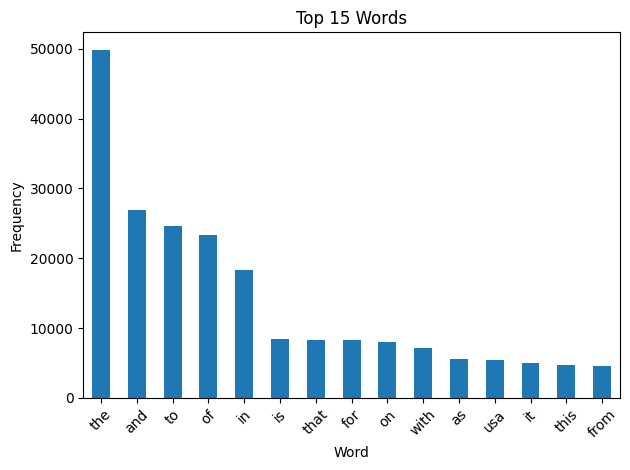

In [ ]:
# bar chart of top 15 words
freq_df.iloc[:15].plot.bar(x='word', y='frequency', legend=False)
plt.title('Top 15 Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###2.4.2 加入停用詞

In [ ]:
# 初次使用需要安裝nltk中的停用字資源
# NLTK stopwords
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
print("Example stop words:", list(stop_words)[:10])

# check if there are 'us' or other specific words in stop words
print("'us' in stop words?", 'us' in stop_words)
print("'usa' in stop words?", 'usa' in stop_words)
print("'iran' in stop words?", 'iran' in stop_words)
print("'attack' in stop words?", 'attack' in stop_words)
print("'war' in stop words?", 'war' in stop_words)

Example stop words: ['themselves', 'shan', 'why', 'did', 'too', 'any', 'didn', 'am', 'which', 'nor']
'us' in stop words? False
'usa' in stop words? False
'iran' in stop words? False
'attack' in stop words? False
'war' in stop words? False


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# ── 去除停用詞 → noStop_df ────────────────────────────────────
noStop_df = stem_df[~stem_df['stem_token'].isin(stop_words)].reset_index(drop=True)
display(noStop_df.head(10))
print(f"移除 stop words 前 token 數: {len(stem_df)}")
print(f"移除 stop words 後 token 數: {len(noStop_df)}")

,title,date,link,content,sentence,tokens,stem_token
0,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,israel,israel
1,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,help
2,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,create,creat
3,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,hamas,hama
4,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,israel,israel
5,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,usa,usa
6,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,created,creat
7,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,hamas,hama
8,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,hezbollah,hezbollah
9,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,al,al


移除 stop words 前 token 數: 930119
移除 stop words 後 token 數: 612322


###2.4.4 重新計算字頻

In [ ]:
# ── 重新計算字頻 ──────────────────────────────────────────────
# count the frequency of each token and make a word frequency dataframe
freq_df = pd.DataFrame(noStop_df['tokens'].value_counts()).reset_index()
freq_df.columns = ['word', 'frequency']
print(freq_df.head(15))

      word  frequency
0      usa       5489
1     this       4727
2      was       4394
3      has       3007
4      his       2487
5     iran       2250
6    trump       2121
7      war       2029
8   israel       1855
9    would       1769
10    like       1628
11    also       1584
12  people       1569
13     one       1520
14     new       1495


###2.4.5 重新繪製長條圖

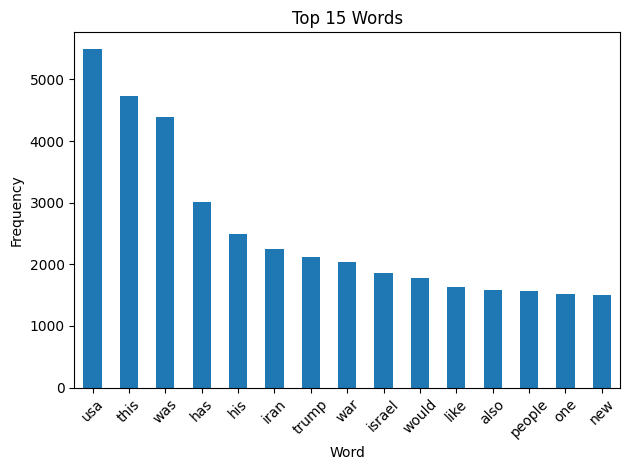

In [ ]:
# ── 長條圖 ────────────────────────────────────────────────────
# bar chart of top 15 words
freq_df.iloc[:15].plot.bar(x='word', y='frequency', legend=False)
plt.title('Top 15 Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

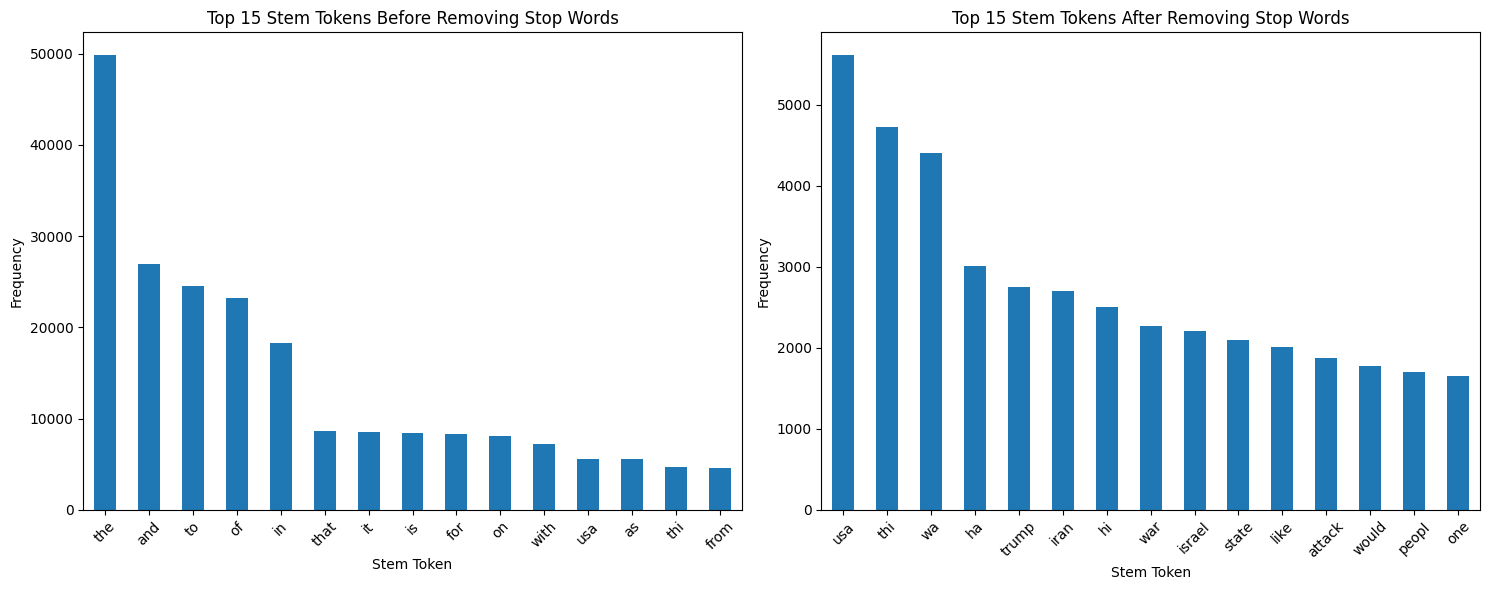

In [ ]:
# Bar charts before and after stop word removal side by side
freq_stem_df_before = pd.DataFrame(stem_df['stem_token'].value_counts()).reset_index()
freq_stem_df_before.columns = ['stem_token', 'frequency']
freq_stem_df_after = pd.DataFrame(noStop_df['stem_token'].value_counts()).reset_index()
freq_stem_df_after.columns = ['stem_token', 'frequency']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
freq_stem_df_before.iloc[:15].plot.bar(x='stem_token', y='frequency', legend=False, ax=axes[0])
axes[0].set_title('Top 15 Stem Tokens Before Removing Stop Words')
axes[0].set_xlabel('Stem Token')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
freq_stem_df_after.iloc[:15].plot.bar(x='stem_token', y='frequency', legend=False, ax=axes[1])
axes[1].set_title('Top 15 Stem Tokens After Removing Stop Words')
axes[1].set_xlabel('Stem Token')
axes[1].set_ylabel('Frequency')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

##2.5 生成文字雲
根據清理和處理後的 Reddit 評論文本，生成文字雲視覺化圖表，以呈現討論中最常出現的關鍵詞和主題。


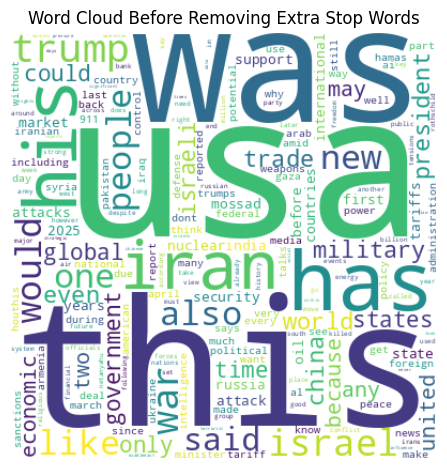

In [ ]:
# ── Step 6: 文字雲 ────────────────────────────────────────────
text1 = freq_df.set_index('word')['frequency'].to_dict()
wordcloud_before = WordCloud(width=400, height=400, background_color='white').generate_from_frequencies(text1)
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Before Removing Extra Stop Words')
plt.tight_layout()
plt.show()

自行再增加停用字

In [ ]:
# add more stop words
newStops = ['one', 'two', 'first', 'years', 'new', 'news', 'time', 'says', 'much', 'still', 'day', 'end', 'want', 'last', 'including', 'since', 'use', 'said', 'may','even', 'many', 'take', 'would', 'also', 'could', 'like']
stop_words.update(newStops)

In [ ]:
# frequency of each stem token after adding new stop words
noStop_df_updated = stem_df[~stem_df['tokens'].isin(stop_words)].reset_index(drop=True)
freq_stem_df_updated = pd.DataFrame(noStop_df_updated['tokens'].value_counts()).reset_index()
freq_stem_df_updated.columns = ['tokens', 'frequency']
print(freq_stem_df_updated.head(20))

        tokens  frequency
0          usa       5489
1         iran       2250
2        trump       2121
3          war       2029
4       israel       1855
5       people       1569
6     military       1310
7        china       1294
8    president       1291
9        trade       1285
10       world       1258
11      global       1134
12  government       1120
13     israeli       1098
14      states       1069
15    economic        971
16      united        941
17     support        900
18         oil        891
19     nuclear        888


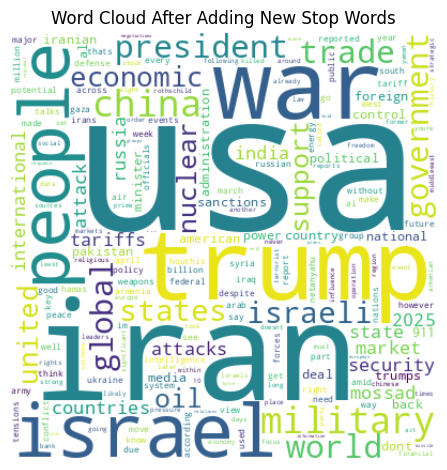

In [ ]:
# word cloud after adding new stop words
text2 = freq_stem_df_updated.set_index('tokens')['frequency'].to_dict()
wordcloud_updated = WordCloud(width=400, height=400, background_color='white').generate_from_frequencies(text2)
plt.imshow(wordcloud_updated, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud After Adding New Stop Words')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Word Cloud After Adding Stop Words')

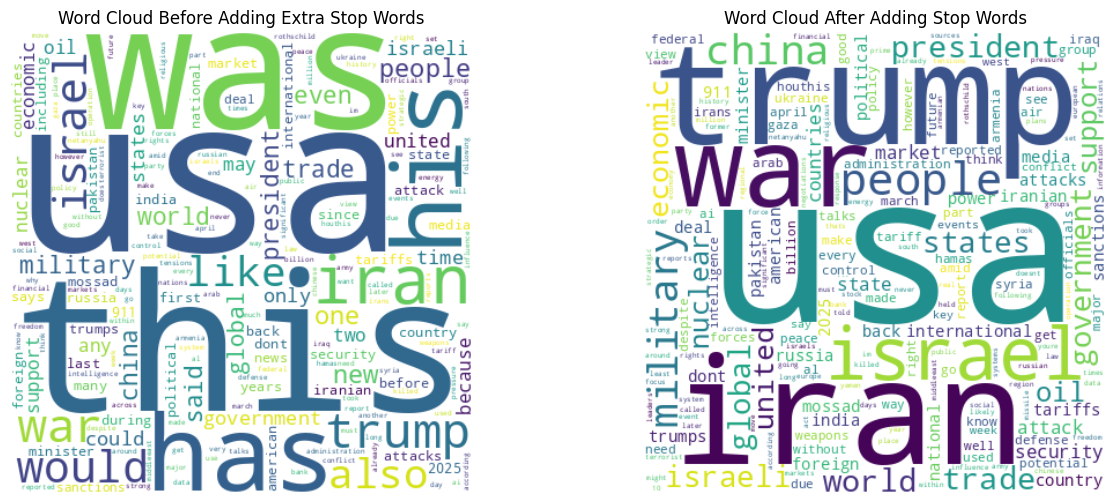

In [ ]:
# a graph containing the word clouds before and after stop words
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
text1 = freq_df.set_index('word')['frequency'].to_dict()
wordcloud_before = WordCloud(width=400, height=400, background_color='white').generate_from_frequencies(text1)
axes[0].imshow(wordcloud_before, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud Before Adding Extra Stop Words')
text2 = freq_stem_df_updated.set_index('tokens')['frequency'].to_dict()
wordcloud_after = WordCloud(width=400, height=400, background_color='white').generate_from_frequencies(text2)
axes[1].imshow(wordcloud_after, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud After Adding Stop Words')

**文字雲觀察與語義分析**

核心焦點：美國與以色列 (US & Israel)
* **關鍵詞：** `US`、`Israel`、`War`
* **意義：** 在 Reddit 鄉民的討論中，「美國」與「以色列」被視為這場衝突中最核心的兩個主體。這顯示大眾傾向將這場戰爭高度與**美國的政策及利益**掛鉤，並認為以色列在其中扮演關鍵角色。

關鍵政治領袖：川普 (Trump)
* **關鍵詞：** `Trump` (字級極大)
* **意義：** 反映了討論具有強烈的**政治導向**。鄉民可能在回顧川普任內的對伊政策（如 2020 蘇萊曼尼事件），或是在 2026 年背景下討論其回歸對未來局勢的衝擊。

軍事與情報色彩 (Military & Intelligence)
* **關鍵詞：** `Mossad` (摩薩德)、`Military`、`Intelligence`
* **意義：** 討論層次不只停留在表面軍事行動，鄉民對於**間諜活動、暗殺行動、情報準確性**有極高的關注與猜測，顯示社群對「影子戰爭」的濃厚興趣。

地域聯動與連鎖反應 (Geopolitics)
* **關鍵詞：** `Pakistan`、`India`、`Russia`、`China`
* **意義：** 鄉民認為美伊戰爭並非孤立事件，而是會牽動全球：
    * **中俄：** 討論中常考慮到其作為「反美陣營」的反應。
    * **印巴：** 涉及南亞國家的立場或潛在的核武局勢。
陰謀論與深層討論 (Deep State/Conspiracy)
* **關鍵詞：** `Rothschild` (羅斯柴爾德家族)
* **意義：** 這是一個指標性的發現。代表資料來源中包含不少**陰謀論色彩**或關於「國際金融勢力影響戰爭」的爭論，這是 Reddit 政治版塊的一大特色。

# 3.執行情緒分析


---


對每條 Reddit 評論執行情緒分析，將其分類為正面、負面或中性情緒，並匯總整體情緒分佈情況。

##3.1 字典法(Lexicon based)

In [ ]:
# 讀取情緒字典
import pandas as pd
from IPython.display import display
en_dict_path = "/content/LIWC_EN.csv"
liwc_dict = pd.read_csv(en_dict_path)
liwc_dict = liwc_dict.rename(columns={'name': 'word', "class": 'sentiments'})
liwc_dict.head(10)

,word,sentiments
0,(:,affect
1,):,affect
2,:(,affect
3,:),affect
4,abandon,affect
5,abuse,affect
6,abusi,affect
7,accept,affect
8,accepta,affect
9,accepted,affect


In [ ]:
# LIWC_dict 字典情感欄位的內容有哪些以及數量
liwc_dict['sentiments'].value_counts()

,count
sentiments,
affect,1416
negative,745
positive,642
anger,230
sad,136
anx,116


In [ ]:
# 統一格式: 轉成字串、小寫化、去掉前後空白
liwc_dict['word'] = liwc_dict['word'].astype(str).str.lower().str.strip()
liwc_dict['sentiments'] = liwc_dict['sentiments'].astype(str).str.lower().str.strip()

In [ ]:
# 只保留字典裡正向與負向
liwc_sent_dict = liwc_dict[liwc_dict['sentiments'].isin(['positive', 'negative'])].copy()

# 幫 LIWC 字典做 stemming
porter = PorterStemmer()
liwc_sent_dict['stem_word'] = liwc_sent_dict['word'].apply(lambda x: porter.stem(x))

print("LIWC 字典前 10 筆：")
display(liwc_sent_dict.head(10))

print("情緒類別分布：")
print(liwc_sent_dict['sentiments'].value_counts())

print("LIWC 字典 stem 後前 10 筆：")
display(liwc_sent_dict[['word', 'stem_word', 'sentiments']].head(10))

LIWC 字典前 10 筆：


,word,sentiments,stem_word
1416,(:,positive,(:
1417,:),positive,:)
1418,accept,positive,accept
1419,accepta,positive,accepta
1420,accepted,positive,accept
1421,accepting,positive,accept
1422,accepts,positive,accept
1423,active,positive,activ
1424,actively,positive,activ
1425,admir,positive,admir


情緒類別分布：
sentiments
negative    745
positive    642
Name: count, dtype: int64
LIWC 字典 stem 後前 10 筆：


,word,stem_word,sentiments
1416,(:,(:,positive
1417,:),:),positive
1418,accept,accept,positive
1419,accepta,accepta,positive
1420,accepted,accept,positive
1421,accepting,accept,positive
1422,accepts,accept,positive
1423,active,activ,positive
1424,actively,activ,positive
1425,admir,admir,positive


## 3.2 情緒字典與斷詞結果進行合併

In [ ]:
# 情緒字典與斷詞結果進行合併
# 用 stem_df
reddit_stems = stem_df.copy() #把原本的 token_df 複製一份出來，叫做 reddit_tokens, reddit_tokens = 專門拿來做 LIWC 情緒比對的工作表
reddit_stems['stem_word'] = reddit_stems['stem_token'].astype(str).str.lower().str.strip()  #合併前的檢查, merge 前的最後格式統一
liwc_sent_dict['stem_word'] = liwc_sent_dict['stem_word'].astype(str).str.lower().str.strip()


# 合併, 合併：用 stem_token 對 stem_word。對到的詞，就會被標上 positive 或 negative。
sentiment_merge_df = pd.merge(
    reddit_stems,
    liwc_sent_dict,
    left_on='stem_token',
    right_on='stem_word',
    how='left'
)

print("合併後筆數：", len(sentiment_merge_df))
display(sentiment_merge_df.head(20))

合併後筆數： 989463


,title,date,link,content,sentence,tokens,stem_token,stem_word_x,word,sentiments,stem_word_y
0,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,how,how,how,NaN,NaN,NaN
1,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,israel,israel,israel,NaN,NaN,NaN
2,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,help,help,helpful,positive,help
3,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,help,help,helpfully,positive,help
4,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,help,help,helpfulness,positive,help
5,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,help,help,helping,positive,help
6,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,help,help,helps,positive,help
7,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,create,creat,creat,create,positive,creat
8,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,create,creat,creat,created,positive,creat
9,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,create,creat,creat,creates,positive,creat


In [ ]:
# 看每天的正負向情緒數量

sentiment_count = pd.DataFrame(
    sentiment_merge_df.groupby(['date', 'sentiments']).size()
).reset_index()

# 只保留 positive / negative
mask = (
    (sentiment_count['sentiments'] == 'positive') |
    (sentiment_count['sentiments'] == 'negative')
)
sentiment_count = sentiment_count.loc[mask]

# 把數量欄位改名成 count
sentiment_count = sentiment_count.rename(columns={0: 'count'})

display(sentiment_count.head(10))

,date,sentiments,count
0,2025-03-13,negative,642
1,2025-03-13,positive,752
2,2025-03-14,negative,394
3,2025-03-14,positive,448
4,2025-03-15,negative,604
5,2025-03-15,positive,679
6,2025-03-16,negative,1652
7,2025-03-16,positive,1287
8,2025-03-18,negative,74
9,2025-03-18,positive,115


## 3.3 觀察發文頻率

,date,size
0,2025-03-13,5
1,2025-03-14,7
2,2025-03-15,5
3,2025-03-16,19
4,2025-03-18,7


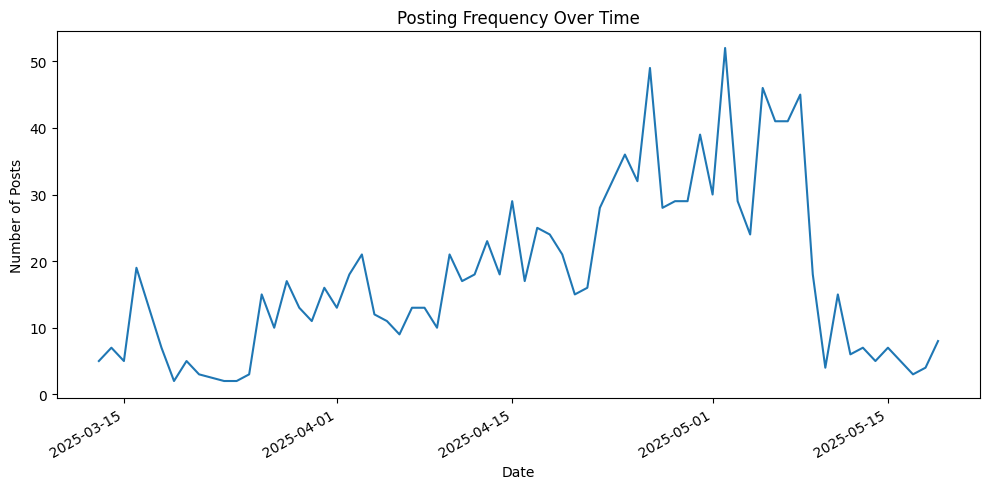

In [ ]:
# 3.3 觀察發文頻率

import pandas as pd
import matplotlib.pyplot as plt

# 用文章層級資料
post_df = clear_df.copy()

# 確保 date 是日期格式
post_df["date"] = pd.to_datetime(post_df["date"])

# 如果只想看日期，不看時間
post_df["date"] = post_df["date"].dt.date

# 依照日期分組，計算每天有幾篇貼文
post_freq_df = post_df.groupby("date", as_index=False).size()

# 看前幾筆結果
display(post_freq_df.head())

# 畫折線圖
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(post_freq_df["date"], post_freq_df["size"])

ax.set_title("Posting Frequency Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Posts")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 3.4 正負向情緒詞彙頻率折線圖圖

  sentiment  count
0  positive  69260
1  negative  45773


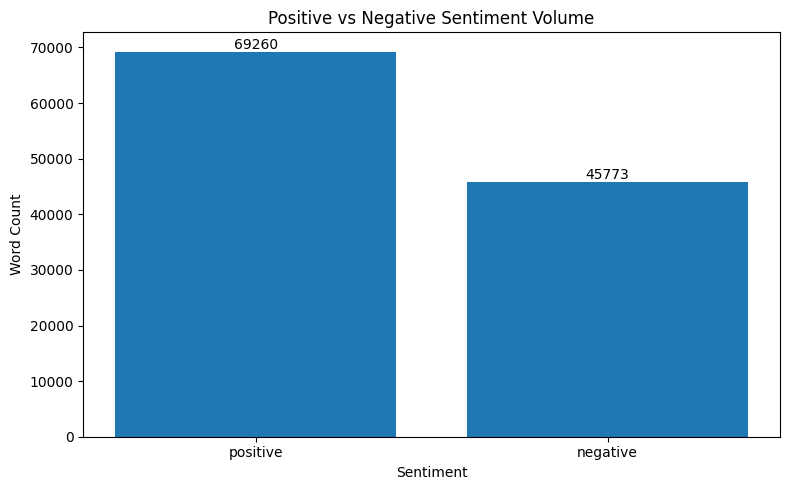

In [ ]:
# 3.3 正負向情緒聲量長條圖
import matplotlib.pyplot as plt

# 把剛剛得到得sentiment_merge_df 抓出sentiments此欄, 在使用 .value_counts() 統計每類別出現幾次, 在使用 .reset_index() 把統計結果轉成dataFrame 方便後面畫表
sentiment_count_df = (
    sentiment_merge_df['sentiments']
    .value_counts()
    .reset_index()
)
sentiment_count_df.columns = ['sentiment', 'count']

print(sentiment_count_df)

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_count_df['sentiment'], sentiment_count_df['count'])

plt.title('Positive vs Negative Sentiment Volume')
plt.xlabel('Sentiment')
plt.ylabel('Word Count')

for bar in bars:
    y = bar.get_height()     ## 取得這類情緒的數量 (positive & negative)

    plt.text(                # 定義x,y 位置 & 圖表layout
        bar.get_x() + bar.get_width()/2,
        y,
        int(y),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

本圖呈現的是以 stem_df + LIWC_EN_stem 方法進行情緒字典比對後的結果。分析流程上，先將 Reddit 貼文中的 token 做 stemming，將不同字尾變化但詞根相近的字收斂為相同詞幹；同時，也將 LIWC_EN 情緒字典中的詞彙進行相同的 stemming 處理，最後再以雙方的 stem 形式進行合併與比對。如此可降低因字形差異造成的匹配遺漏，例如 helped、helping、helps 等詞，都有機會收斂至相近的 stem，提升情緒詞的辨識率。

從圖中結果可看出，經過 stem 對 stem 的比對後，被判定為 positive 的情緒詞共有 69,264 個，而被判定為 negative 的情緒詞共有 45,773 個，顯示在本次 Reddit「US Iran war」討論資料中，正向情緒詞的出現量高於負向情緒詞。需要特別說明的是，此圖統計的是情緒詞彙的數量，亦即有多少個字詞在比對後被標記為 positive 或 negative，而不是整篇貼文的情緒篇數。因此，這張圖反映的是資料在字詞層級上的情緒聲量分布。

相較於直接使用 token_df + LIWC_EN 的原始字詞比對方式，stem_df + LIWC_EN_stem 的優點在於能將相同字根但字尾不同的詞彙加以收斂，減少因 -ed、-ing、-s 等字尾變化而無法成功匹配的情況，使情緒字典法在詞彙辨識上更具延展性與涵蓋性。綜合而言，本結果顯示使用 stemming 後，能更有效掌握討論文本中的情緒詞分布，並提升整體情緒分析的匹配機會。



## 3.5 正負向情緒詞彙比例折線圖圖

In [ ]:
# 3.4 正負向情緒比例折線圖

#先算每天各種情緒有幾筆
daily_sentiment_counts = (
    sentiment_merge_df.groupby(['date', 'sentiments'])
    .size()
    .reset_index(name='count')
)

#把表格轉成比較好算比例的形式
daily_sentiment_pivot = daily_sentiment_counts.pivot(
    index='date',
    columns='sentiments',
    values='count'
).fillna(0)


# 避免某一天只有單一情緒類別, 防呆:怕某一天或某批資料只出現單一情緒，導致 pivot() 後缺欄位，所以先補 0，讓後面算總數和比例時不會炸掉。
for col in ['positive', 'negative']:
    if col not in daily_sentiment_pivot.columns:
        daily_sentiment_pivot[col] = 0


#算每天情緒詞總數
daily_sentiment_pivot['total'] = (
    daily_sentiment_pivot['positive'] + daily_sentiment_pivot['negative']
)

daily_sentiment_pivot = daily_sentiment_pivot[daily_sentiment_pivot['total'] > 0].copy()


#算每天正向比例
daily_sentiment_pivot['positive_ratio'] = (
    daily_sentiment_pivot['positive'] / daily_sentiment_pivot['total']
)

#算每天負向比例
daily_sentiment_pivot['negative_ratio'] = (
    daily_sentiment_pivot['negative'] / daily_sentiment_pivot['total']
)

#依日期排序
daily_sentiment_pivot = daily_sentiment_pivot.sort_index()

display(daily_sentiment_pivot.head())

sentiments,negative,positive,total,positive_ratio,negative_ratio
date,,,,,
2025-03-13,642,752,1394,0.539455,0.460545
2025-03-14,394,448,842,0.532067,0.467933
2025-03-15,604,679,1283,0.529228,0.470772
2025-03-16,1652,1287,2939,0.437904,0.562096
2025-03-18,74,115,189,0.608466,0.391534


從表中可見，例如 2025-03-13 的正向情緒詞為 752 個，負向情緒詞為 642 個，總情緒詞數為 1394 個，因此當日正向比例約為 53.95%，負向比例約為 46.05%；而 2025-03-16 則呈現相反情況，正向情緒詞為 1287 個，負向情緒詞為 1652 個，負向比例約為 56.21%，高於正向比例的 43.79%。這表示不同日期之間，討論情緒會隨著事件脈絡而有所波動。

需要特別說明的是，這裡統計的不是「每天有多少正向貼文或負向貼文」，而是每天被 LIWC 字典辨識出的正向與負向情緒詞數量及其比例，因此反映的是字詞層級的情緒分布，而非整篇文章層級的情緒分類。透過這種方式，可以更細緻地觀察每日討論語彙的情緒傾向，並進一步比較不同日期之間正負向情緒的變化。

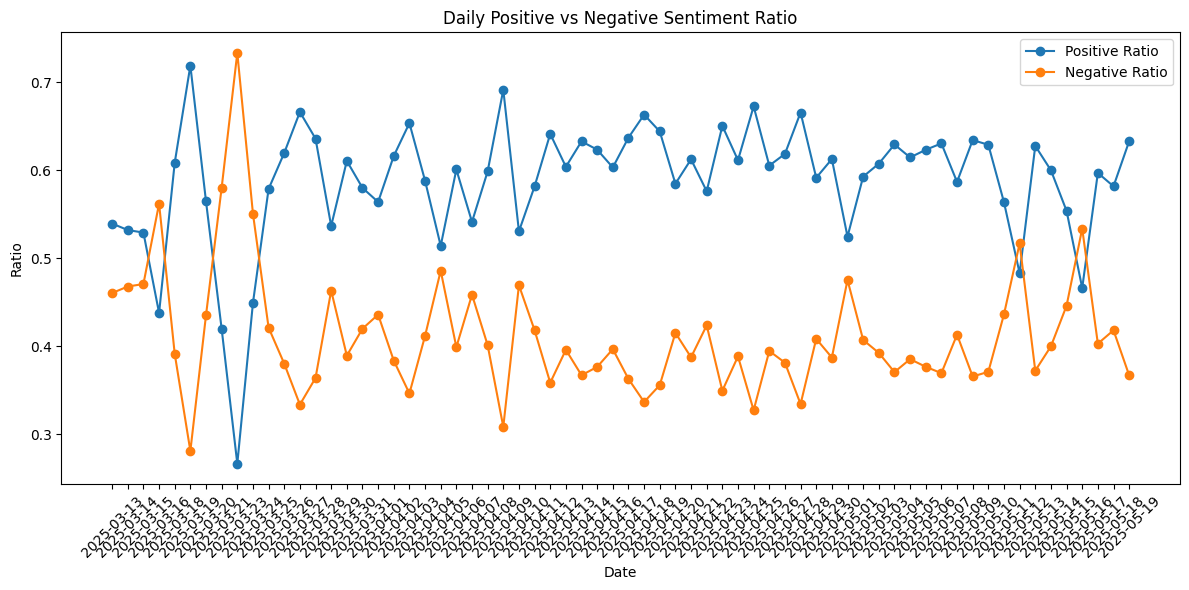

In [ ]:
plt.figure(figsize=(12, 6))

#正向比例折線
plt.plot(
    daily_sentiment_pivot.index,
    daily_sentiment_pivot['positive_ratio'],
    marker='o',
    label='Positive Ratio'
)

#負向比例折線
plt.plot(
    daily_sentiment_pivot.index,
    daily_sentiment_pivot['negative_ratio'],
    marker='o',
    label='Negative Ratio'
)

# 圖表layout
plt.title('Daily Positive vs Negative Sentiment Ratio')
plt.xlabel('Date')
plt.ylabel('Ratio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

本圖呈現的是以 stem_df + LIWC_EN_stem 方法進行情緒字典比對後，每日正向與負向情緒詞比例的變化趨勢。圖中藍線代表正向情緒詞比例，橘線代表負向情緒詞比例。整體而言，多數日期中正向比例高於負向比例，顯示在字詞層級上，討論語彙多偏向正向；但部分日期負向比例明顯上升，反映特定時間點的討論內容可能出現較多負面、緊張或批評性的情緒表達。與前一張長條圖相比，此圖更能呈現情緒比例隨時間變化的趨勢，而不僅僅是整體總量差異。

## 3.6 正負向情緒分數折線圖

In [ ]:
import matplotlib.pyplot as plt
import platform

# 根據作業系統自動切換字型
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
elif system == 'Darwin': # Mac
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
else: # Linux / Colab
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans'] # 預設字型

plt.rcParams['axes.unicode_minus'] = False

# 1,計算每日正負向情緒數量。
# 資料宣告 Data dictionary
# dailysentiment_sc_pivot
# sentiment_score # 正負向情緒分數

#先算每天各種情緒有幾筆
daily_sentiment_counts = (
    sentiment_merge_df.groupby(['date','sentiments'])
    .size()
    .reset_index(name='count')
)

#把表格轉成比較好算比例的形式
daily_sentiment_pivot = daily_sentiment_counts.pivot(
    index='date',
    columns='sentiments',
    values='count'
).fillna(0)


# 避免某一天只有單一情緒類別, 防呆:怕某一天或某批資料只出現單一情緒，導致 pivot() 後缺欄位，所以先補 0，讓後面算總數和比例時不會炸掉。
for col in ['positive', 'negative']:
    if col not in daily_sentiment_pivot.columns:
        daily_sentiment_pivot[col] = 0

#算每天情緒詞總數
daily_sentiment_pivot['total'] = (
    daily_sentiment_pivot['positive'] + daily_sentiment_pivot['negative']
)

daily_sentiment_pivot = daily_sentiment_pivot[daily_sentiment_pivot['total'] > 0].copy()

# 計算每天，正向-負向 ,
daily_sentiment_pivot['sentiment_score'] = (
    daily_sentiment_pivot['positive'] - daily_sentiment_pivot['negative']
)


#依日期排序
daily_sentiment_pivot = daily_sentiment_pivot.sort_index()

display(daily_sentiment_pivot.head())


sentiments,negative,positive,total,sentiment_score
date,,,,
2025-03-13,195,169,364,-26
2025-03-14,107,92,199,-15
2025-03-15,204,112,316,-92
2025-03-16,474,320,794,-154
2025-03-18,15,23,38,8


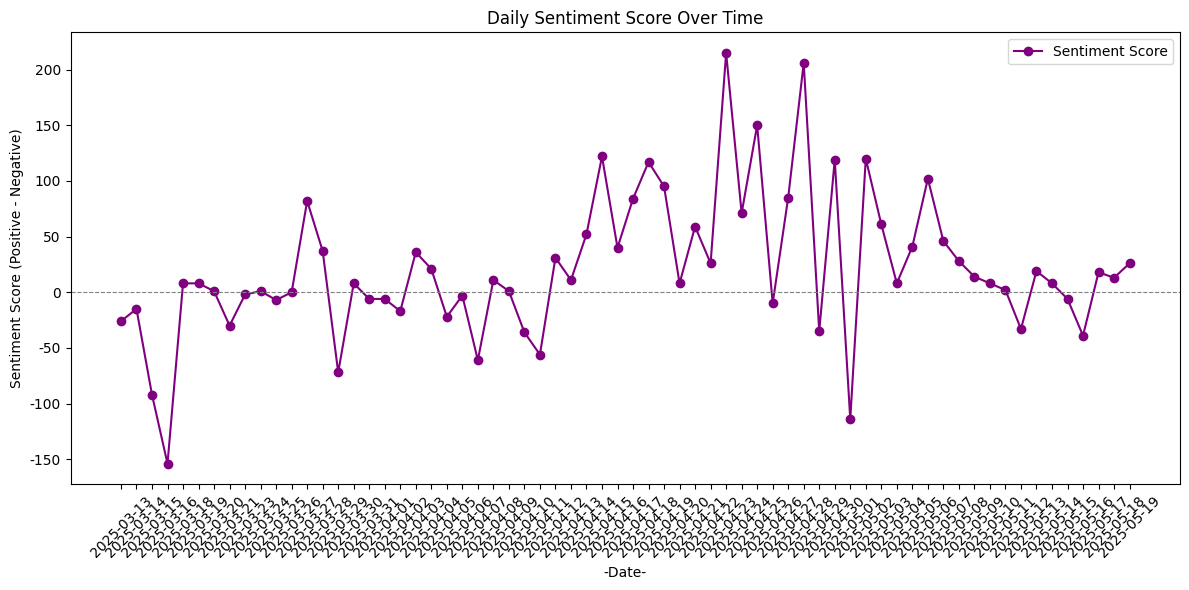

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# 情緒分數折線圖
plt.plot(
    daily_sentiment_pivot.index,
    daily_sentiment_pivot['sentiment_score'],
    marker='o',
    label='Sentiment Score',
    color='purple'
)

# 圖表layout
plt.title('Daily Sentiment Score Over Time')
plt.xlabel('-Date-')
plt.ylabel('Sentiment Score (Positive - Negative)')
plt.xticks(rotation=45)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Sentiment Trend')

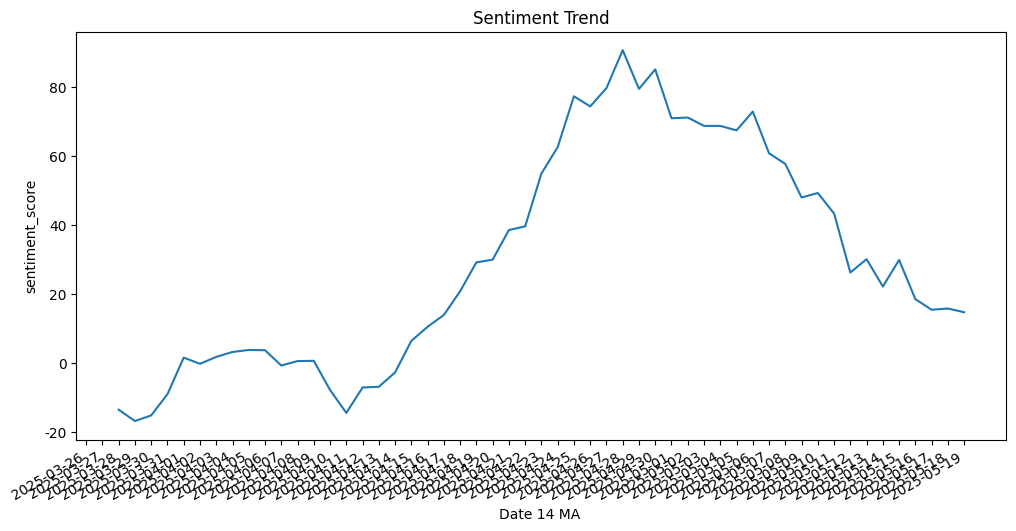

In [ ]:

# output 情緒分數折線圖
fig,ax = plt.subplots(figsize=(12,6))
rolliing_day = 14

ax.plot( daily_sentiment_pivot.index,daily_sentiment_pivot['sentiment_score'].rolling(rolliing_day).mean(),
label='14MA')

ax.set_xlabel('Date 14 MA ')
ax.set_ylabel('sentiment_score')
fig.autofmt_xdate()
plt.title('Sentiment Trend') # 若字型失效，建議標題用英文避開方塊


## 3.7 文章為單位的情緒分數折線圖






In [ ]:
#3.7.1

# sentiment_merge_df  原始文章
sentiment_merge_df

#先算每天各種文章情緒有幾筆
sentiment_count_by_article = pd.DataFrame(
    sentiment_merge_df.groupby(['link', 'sentiments']).size()
).reset_index()

sentiment_count_by_article =sentiment_count_by_article.rename(columns={0 : "size"})
sentiment_count_by_article.head(10)


,link,sentiments,size
0,http://x.com,negative,10
1,http://x.com,positive,12
2,https://DrJorge.World,negative,21
3,https://DrJorge.World,positive,36
4,https://apnews.com/article/gaza-israel-hamas-c...,negative,1
5,https://apnews.com/article/gaza-israel-hamas-c...,positive,2
6,https://arabcenterdc.org/resource/saudi-arabia...,negative,20
7,https://arabcenterdc.org/resource/saudi-arabia...,positive,37
8,https://armyrecognition.com/news/navy-news/202...,negative,6
9,https://armyrecognition.com/news/navy-news/202...,positive,3


In [ ]:
#3.7.2

#convert sentiment Table
# 輚換 情緒正負 分群計算

sentiment_value_by_article = (sentiment_count_by_article.pivot_table(
    index='link',
    columns='sentiments',
    values='size',
    aggfunc='sum',
    ).reset_index().fillna(0))

sentiment_value_by_article.head(10)


sentiments,link,negative,positive
0,http://x.com,10.0,12.0
1,https://DrJorge.World,21.0,36.0
2,https://apnews.com/article/gaza-israel-hamas-c...,1.0,2.0
3,https://arabcenterdc.org/resource/saudi-arabia...,20.0,37.0
4,https://armyrecognition.com/news/navy-news/202...,6.0,3.0
5,https://bulgarianmilitary.com/2025/04/04/iran-...,0.0,2.0
6,https://bulgarianmilitary.com/2025/04/21/israe...,1.0,0.0
7,https://bulgarianmilitary.com/2025/05/05/houth...,2.0,0.0
8,https://claude.ai,7.0,7.0
9,https://drjorge.world/2025/05/06/the-borders-w...,72.0,54.0


In [ ]:
#3.7.3 計算情緒分數，並設置正負向label

# 計算一文章的情緒分數，正向-負向 ,
sentiment_value_by_article['sentiment_aritcle_score'] = (
    sentiment_value_by_article['positive'] - sentiment_value_by_article['negative']
)
# 並設置正負向 label
sentiment_value_by_article['sentiment_class'] = sentiment_value_by_article['sentiment_aritcle_score'].apply(lambda x: 'positive' if x > 0 else ('negative' if x < 0 else 'neutral'))
sentiment_value_by_article.head(10)


sentiments,link,negative,positive,sentiment_aritcle_score,sentiment_class
0,http://x.com,10.0,12.0,2.0,positive
1,https://DrJorge.World,21.0,36.0,15.0,positive
2,https://apnews.com/article/gaza-israel-hamas-c...,1.0,2.0,1.0,positive
3,https://arabcenterdc.org/resource/saudi-arabia...,20.0,37.0,17.0,positive
4,https://armyrecognition.com/news/navy-news/202...,6.0,3.0,-3.0,negative
5,https://bulgarianmilitary.com/2025/04/04/iran-...,0.0,2.0,2.0,positive
6,https://bulgarianmilitary.com/2025/04/21/israe...,1.0,0.0,-1.0,negative
7,https://bulgarianmilitary.com/2025/05/05/houth...,2.0,0.0,-2.0,negative
8,https://claude.ai,7.0,7.0,0.0,neutral
9,https://drjorge.world/2025/05/06/the-borders-w...,72.0,54.0,-18.0,negative


In [ ]:
#3.7.4 合併計算一文章的情緒分數，正向-負向 標籤 ，與主文合併。

article_df_sentment = pd.merge(sentiment_merge_df,sentiment_value_by_article[['link','sentiment_aritcle_score','sentiment_class']],how='left')
article_df_sentment.head(10)

# 影片日期轉換，本段略過。



,title,date,link,content,sentence,tokens,word,sentiments,sentiment_aritcle_score,sentiment_class
0,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,how,NaN,NaN,14.0,positive
1,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,israel,NaN,NaN,14.0,positive
2,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,helped,NaN,NaN,14.0,positive
3,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,create,create,positive,14.0,positive
4,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,hamas,NaN,NaN,14.0,positive
5,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,israel,NaN,NaN,14.0,positive
6,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,and,NaN,NaN,14.0,positive
7,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,usa,NaN,NaN,14.0,positive
8,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,created,created,positive,14.0,positive
9,Watch well-researched Legend of Legends Dave S...,2025-05-19,https://v.redd.it/kgx74u092q1f1,"""How Israel helped create Hamas"" https://www.w...",how israel helped create hamas israel and usa ...,hamas,NaN,NaN,14.0,positive


In [ ]:
# 3.7.5

# 依日期排序sentiment_article_by_count

sentiment_article_by_count = pd.DataFrame(
    article_df_sentment.groupby(['date', 'sentiment_class']).size()
).reset_index()

sentiment_article_by_count = sentiment_article_by_count.rename(columns={0 : "size"})
sentiment_article_by_count = sentiment_article_by_count.sort_values(by='date')

sentiment_article_by_count.head()


,date,sentiment_class,size
0,2025-03-13,negative,8192
1,2025-03-13,neutral,1223
2,2025-03-14,negative,1204
3,2025-03-14,neutral,3815
4,2025-03-14,positive,163


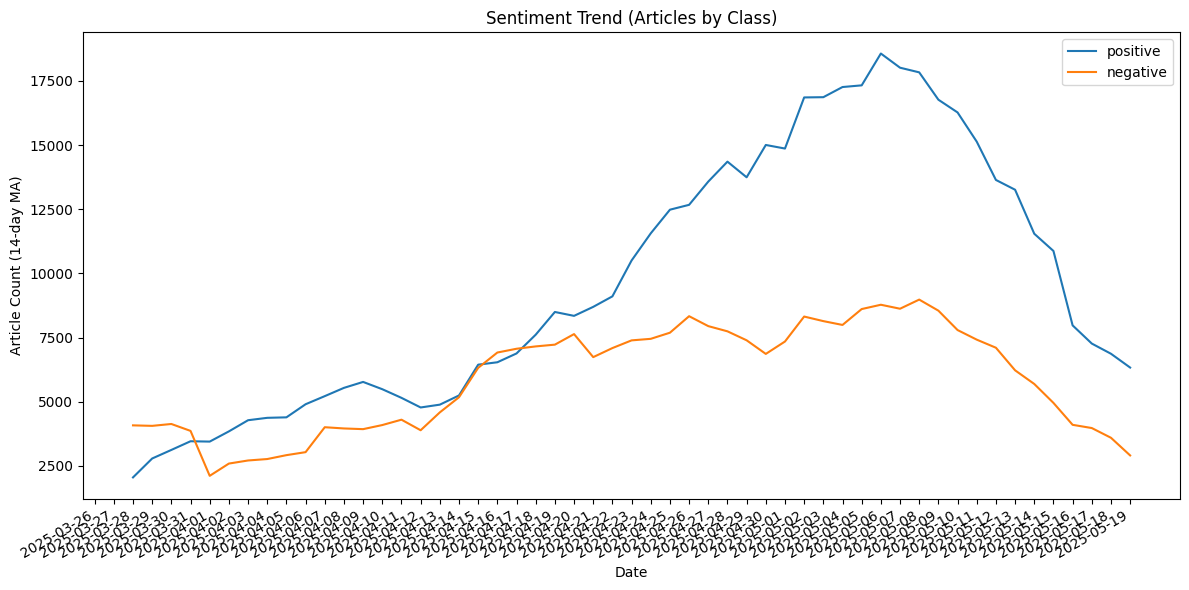

In [ ]:
# draw Line chart

import matplotlib.pyplot as plt

# Pivot the DataFrame to have sentiment_class as columns and date as index
sentiment_pivot = sentiment_article_by_count.pivot(index='date', columns='sentiment_class', values='size').fillna(0)

colors = {'positive': 'tab:blue', 'negative': 'tab:orange', 'neutral': 'tab:green'}

fig, ax = plt.subplots(figsize=(12, 6))
rolliing_day = 14

# Plot rolling mean for positive sentiment
ax.plot(
    sentiment_pivot.index,
    sentiment_pivot['positive'].rolling(rolliing_day).mean(),
    color=colors['positive'],
    label='Positive Sentiment (14-day MA)'
)

# Plot rolling mean for negative sentiment
ax.plot(
    sentiment_pivot.index,
    sentiment_pivot['negative'].rolling(rolliing_day).mean(),
    color=colors['negative'],
    label='Negative Sentiment (14-day MA)'
)

# Optional: Plot rolling mean for neutral sentiment
# ax.plot(
#     sentiment_pivot.index,
#     sentiment_pivot['neutral'].rolling(rolliing_day).mean(),
#     color=colors['neutral'],
#     label='Neutral Sentiment (14-day MA)'
# )

ax.set_xlabel('Date')
ax.set_ylabel('Article Count (14-day MA)')
ax.set_title('Sentiment Trend (Articles by Class)')
ax.legend(['positive','negative'],loc='upper right')

fig.autofmt_xdate()
#plt.grid(True)
plt.tight_layout()
plt.show()

## 3.8 情緒代表字

In [ ]:
# 3.8.1

# 以原文章計算,情續字數

wordcount =  pd.DataFrame(
    sentiment_merge_df.groupby(['word', 'sentiments']).size()
).reset_index()

wordcount = wordcount.rename(columns={0 : "size"})
wordcount = wordcount.sort_values(by='size',ascending=False)

wordcount.head()



,word,sentiments,size
759,war,negative,2031
672,support,positive,900
39,attack,negative,839
390,intelligence,positive,577
502,peace,positive,534


In [ ]:
＃3.8.2

# 計算正向代表字。positive

word_of_pos = wordcount.loc[wordcount['sentiments'] == 'positive']
word_of_pos.head(15)


,word,sentiments,size
672,support,positive,900
390,intelligence,positive,577
502,peace,positive,534
790,well,positive,493
288,good,positive,445
498,party,positive,372
648,strong,positive,369
265,free,positive,313
296,great,positive,300
21,agreement,positive,268


In [ ]:
# 3.8.3
# 計算負向代表字。negative

word_of_neg = wordcount.loc[wordcount['sentiments'] == 'negative']
word_of_neg.head(10)

,word,sentiments,size
759,war,negative,2031
39,attack,negative,839
154,defense,negative,531
245,fight,negative,259
699,terror,negative,252
138,cut,negative,236
707,threat,negative,234
582,risk,negative,228
770,wars,negative,228
754,violence,negative,214


In [ ]:
#3.8.4
#剔除非正負向 屬性文字。（先略過）


## 3.9 文字雲

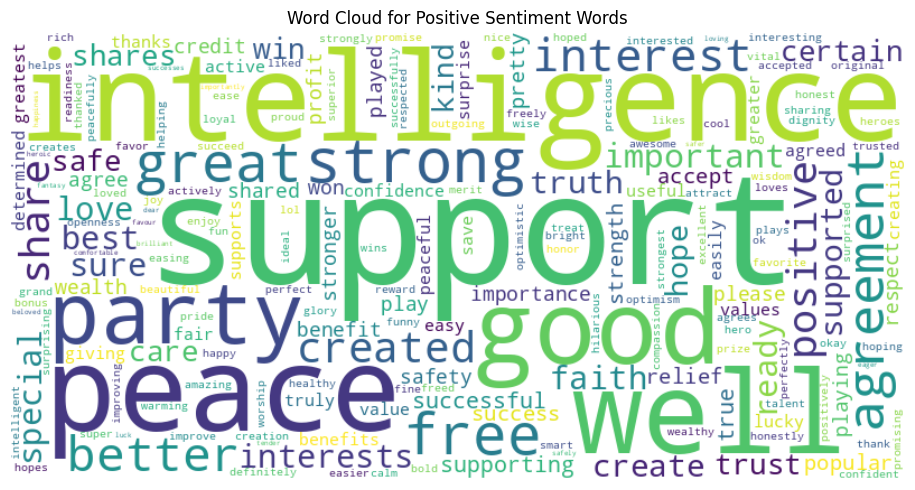

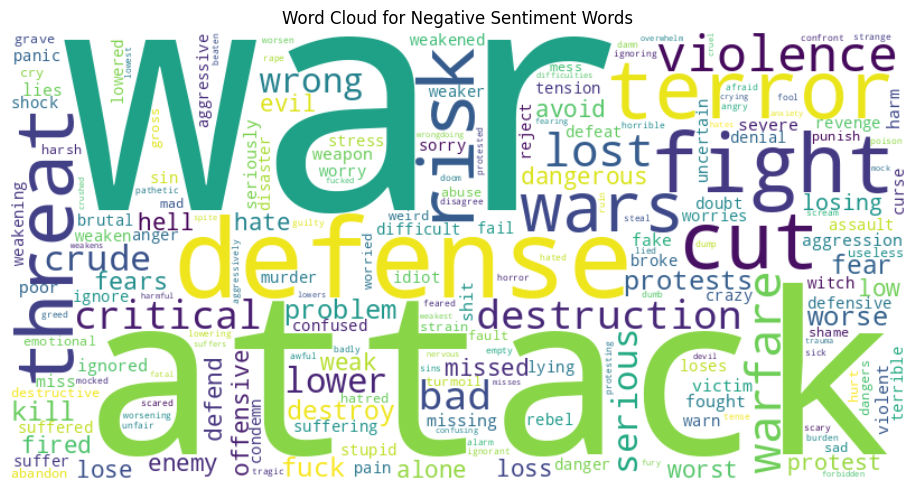

In [ ]:
# 3.9.1
# Draw text cloud

# Word cloud for positive words
text_pos = word_of_pos.set_index('word')['size'].to_dict()
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(text_pos)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Sentiment Words')
plt.tight_layout()
plt.show()

# Word cloud for negative words
text_neg = word_of_neg.set_index('word')['size'].to_dict()
wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(text_neg)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Sentiment Words')
plt.tight_layout()
plt.show()

# 4.執行情緒分析二
---





## 4.1 套件安裝

In [ ]:
# !pip install stanza
import stanza
from stanza.server import CoreNLPClient

import os
import pandas as pd

from nltk.parse import CoreNLPParser
from nltk.parse.corenlp import *
from nltk.corpus import stopwords

from wordcloud import WordCloud

import matplotlib.pyplot as plt

# stanza.install_corenlp("./stanza_corenlp") # 下載coreNLP模型，預設會在/stanza_corenlp裡面

os.environ['CORENLP_HOME'] = "./stanza_corenlp" # 因為自訂下載路徑，所以要設定環境參數

In [ ]:
# 設定 CoreNLPClient with some basic annotators, a memory allocation of 8GB, and increased timeout

client = None
for port_num in range(9999, 10005): # Try a few ports starting from 9999
    try:
        client = CoreNLPClient(
            annotators=['tokenize','ssplit','pos','lemma','ner','entitymentions', 'parse', 'sentiment'],
            memory='4G',
            endpoint=f'http://localhost:{port_num}',
            timeout=30000000, # 增加逾時設定至 1200 秒
            be_quiet=True
        )
        client.start()
        import time; time.sleep(5)
        break # 成功啟動則跳出迴圈
    except Exception as e:
        print(f"Port {port_num} failed: {e}")
        continue

2026-03-28 22:42:40 INFO: Writing properties to tmp file: corenlp_server-081b050b0ad24120.props
2026-03-28 22:42:40 INFO: Starting server with command: java -Xmx4G -cp ./stanza_corenlp/* edu.stanford.nlp.pipeline.StanfordCoreNLPServer -port 9999 -timeout 30000000 -threads 5 -maxCharLength 100000 -quiet True -serverProperties corenlp_server-081b050b0ad24120.props -annotators tokenize,ssplit,pos,lemma,ner,entitymentions,parse,sentiment -preload -outputFormat serialized


拿資料清洗後，斷詞前的sent_df的結果測試

In [ ]:
import pandas as pd

# 讀取 Excel
file_path = "reddit_results.xlsx"   # ← 改成你的路徑
sent_df = pd.read_excel(file_path)
# 確認欄位名稱
print(sent_df.columns)
# 取出 SENTENCE 欄位（第 0 筆）
text = sent_df["SENTENCE"].iloc[0]
# 丟進 CoreNLP
document = client.annotate(text)
# 查看結果型態
print(type(document))

Index(['TITLE', 'DATE', 'LINK', 'CONTENT', 'SENTENCE'], dtype='object')
<class 'CoreNLP_pb2.Document'>
<class 'CoreNLP_pb2.Document'>


## 4.2 利用coreNLP進行自然語言處理

實現斷詞、詞性標註、詞形還原、命名實體辨識


*   Lemmatization：詞性還原（原始的時態）
*   POS：詞性標注
*   NER：命名實體辨識，辨識句子中的人名、地名、組織名稱等等


In [ ]:
# 依序處理每個句子
for i, sent in enumerate(document.sentence):
    # 取得斷句結果：將該句內所有 token 的文字連接起來
    sentence_text = "".join([token.word for token in sent.token])
    print(f"sentence {i+1} 斷句結果: {sentence_text}")

    # 輸出段詞詳細資訊，依據指定格式印出 token 的 word、lemma、pos 與 ner
    for t in sent.token:
        print("{:12s}\t{:12s}\t{:6s}\t{}".format(t.word, t.lemma, t.pos, t.ner))
    print("")

sentence 1 斷句結果: "howisraelhelpedcreatehamas""israelandtheu.s.createdhamas,hezbollahandalqaeda""alltheevidencepointtothefactthatisiswascreatedbytheusisraelandfundedbysaudiarabia""whyisraelhelpedcreatehamas"inotherwords,bysecretlysupportingagroupthatdoesnotrecognizetheexistenceofthestateofisraelanddoesnotacceptatwo-statesolution,israeldoesnothavetoaccepttheexistenceofapalestinianstateanddoesnothavetosupportatwo-statesolution,either.
"           	"           	``    	O
how         	how         	WRB   	O
israel      	israel      	NNP   	COUNTRY
helped      	help        	VBD   	O
create      	create      	VB    	O
hamas       	hama        	NNS   	O
"           	"           	''    	O
"           	"           	``    	O
israel      	israel      	NN    	COUNTRY
and         	and         	CC    	O
the         	the         	DT    	O
u.s.        	u.s.        	JJ    	COUNTRY
created     	create      	VBN   	O
hamas       	hama        	NNS   	O
,           	,           	,     	O
hezbollah   	hezbolla

在NER的部分，有時候會出現人名、地名是名詞詞組，除了上面用單詞標註的ner，我們可以利用entitymentions把名詞詞組拿出來

In [ ]:

for i, sent in enumerate(document.sentence):
    print(f"{'Words':12s}\t{'NER'}\n{'-' * 50}")
    for mention in sent.mentions:
        print(mention.entityMentionText, mention.ner)
    s = ""
    for t in sent.token:
        s = s + t.word + " "
    print(f"sentence{i}: {s}\n")

Words       	NER
--------------------------------------------------
israel COUNTRY
israel COUNTRY
u.s. COUNTRY
al qaeda IDEOLOGY
israel COUNTRY
saudi arabia COUNTRY
israel COUNTRY
state of israel COUNTRY
two-state NUMBER
israel COUNTRY
palestinian NATIONALITY
two-state NUMBER
sentence0: " how israel helped create hamas " " israel and the u.s. created hamas , hezbollah and al qaeda " " all the evidence point to the fact that isis was created by the us israel and funded by saudi arabia " " why israel helped create hamas " in other words , by secretly supporting a group that does not recognize the existence of the state of israel and does not accept a two - state solution , israel does not have to accept the existence of a palestinian state and does not have to support a two - state solution , either . 

Words       	NER
--------------------------------------------------
israel COUNTRY
iraq COUNTRY
israel COUNTRY
iraq COUNTRY
israeli NATIONALITY
thursday DATE
sentence1: " report : israel 

## 4.3 利用coreNLP進行情緒標注

In [ ]:
mapping = {
    "Very negative": 0,
    "Negative": 1,
    "Neutral": 2,
    "Positive": 3,
    "Very positive": 4
}

def sentiment_(text):
    try:
        doc = client.annotate(text)

        scores = [mapping[s.sentiment] for s in doc.sentence]

        if len(scores) == 0:
            return None

        return sum(scores) / len(scores)

    except:
        return None


# 取前100筆資料
sample_df = sent_df.head(100)
# 1️⃣ 算數值
sample_df['sentiment'] = sample_df["SENTENCE"].apply(sentiment_)

# 2️⃣ 轉分類
def sentiment_label(score):
    if score is None:
        return None
    elif score < 1:
        return "Very negative"
    elif score < 2:
        return "Negative"
    elif score < 3:
        return "Neutral"
    elif score < 4:
        return "Positive"
    else:
        return "Very positive"

sample_df['sentiment_label'] = sample_df['sentiment'].apply(sentiment_label)

# 顯示結果
print(sample_df.head())

INFO:stanza:Starting server with command: java -Xmx4G -cp ./stanza_corenlp/* edu.stanford.nlp.pipeline.StanfordCoreNLPServer -port 9999 -timeout 30000000 -threads 5 -maxCharLength 100000 -quiet True -serverProperties corenlp_server-d127acf79964438b.props -annotators tokenize,ssplit,pos,lemma,ner,entitymentions,parse,sentiment -preload -outputFormat serialized
INFO:stanza:Starting server with command: java -Xmx4G -cp ./stanza_corenlp/* edu.stanford.nlp.pipeline.StanfordCoreNLPServer -port 9999 -timeout 30000000 -threads 5 -maxCharLength 100000 -quiet True -serverProperties corenlp_server-d127acf79964438b.props -annotators tokenize,ssplit,pos,lemma,ner,entitymentions,parse,sentiment -preload -outputFormat serialized
/usr/local/lib/python3.12/dist-packages/stanza/protobuf/__init__.py:23: RuntimeWarning: Failed to decode a serialized output from CoreNLP server. An incomplete or empty object will be returned.
  warnings.warn("Failed to decode a serialized output from CoreNLP server. An inco

                                               TITLE        DATE  \
0  Watch well-researched Legend of Legends Dave S...  2025-05-19   
1  The Rt. Hon. Sir Iain Duncan Smith MP on How t...  2025-05-19   
2  we got US SENATORS questioning 9/11 inside job...  2025-05-18   
3  What percent of Americans believe a Muslim hij...  2025-05-18   
4  I asked CHAT GPT about these troubled times an...  2025-05-17   

                                                LINK  \
0                    https://v.redd.it/kgx74u092q1f1   
1  https://www.youtube.com/live/BPxG0jSrx1Y?si=Pj...   
2                    https://v.redd.it/0v9sv5rugg1f1   
3                    https://v.redd.it/9umkll1v8g1f1   
4  https://www.reddit.com/r/Christianity/comments...   

                                             CONTENT  \
0  "How Israel helped create Hamas" https://www.w...   
1  Sir Iain Duncan Smith MP, former leader of the...   
2  #What if the same Cartel that did Epstein Isla...   
3  Good article on how the Rot

/tmp/ipykernel_16687/1536483473.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['sentiment'] = sample_df["SENTENCE"].apply(sentiment_)
/tmp/ipykernel_16687/1536483473.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['sentiment_label'] = sample_df['sentiment'].apply(sentiment_label)


In [ ]:
# sent_df.to_csv("data/corenlp_processed_sentiment.csv")
sample_df.to_csv("sample_corenlp_processed_sentiment.csv")

In [ ]:
import pandas as pd

# 讀取
file_path = "sample_corenlp_processed_sentiment.csv"
sample_df = pd.read_csv(file_path)

# 確認欄位名稱
print(sample_df.columns)


# 將日期轉換為 datetime 格式
sample_df["DATE"] = pd.to_datetime(sample_df["DATE"])

# 依「年月」與「sentiment」分組，計算筆數
grouped = (
  sample_df.groupby([
      sample_df["DATE"].dt.strftime("%Y-%m"),
      "sentiment_label"
  ])
  .size()
  .reset_index(name="size")
)

grouped.columns = ["Month", "sentiments", "size"]

# 印出結果
grouped

Index(['Unnamed: 0', 'title', 'date', 'link', 'content', 'sentence',
       'sentiment', 'sentiment_label'],
      dtype='object')


,Month,sentiments,size
0,2025-05,Negative,5


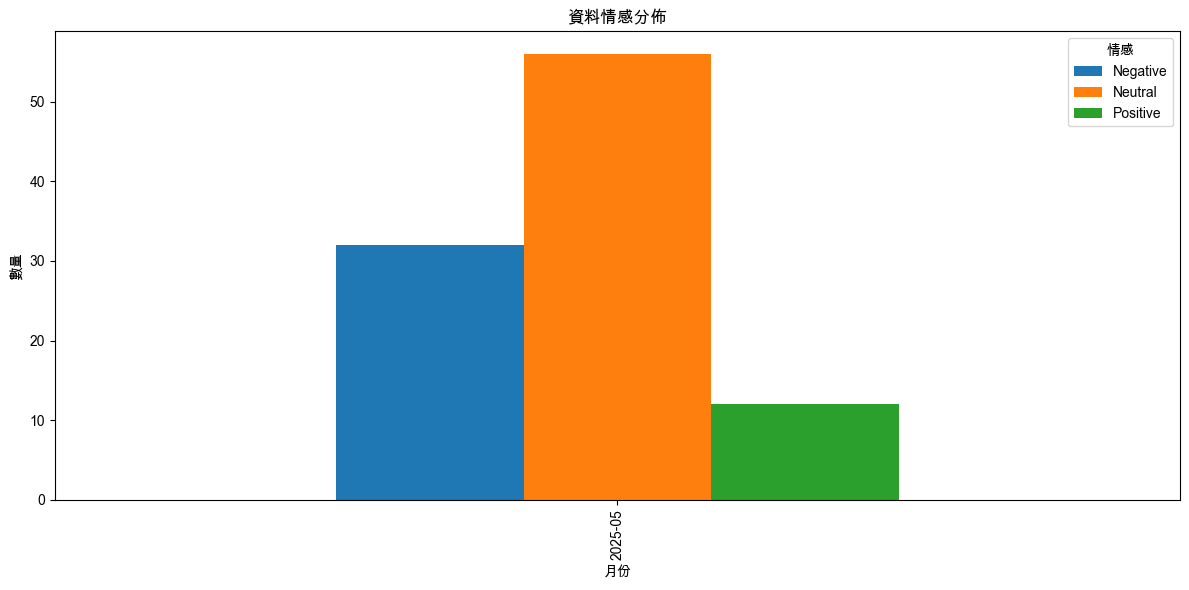

In [ ]:
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd


# 設定中文字型（放前面OK）
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
matplotlib.rcParams['axes.unicode_minus'] = False  # 避免負號變亂碼


df_pivot = grouped.pivot_table(index='Month', columns='sentiments', values='size', aggfunc='sum', fill_value=0)

# 繪製直條圖
df_pivot.plot(kind='bar', figsize=(12, 6))
plt.title("資料情感分佈")
plt.xlabel("月份")
plt.ylabel("數量")
plt.legend(title="情感")
plt.tight_layout()
plt.show()

## 4.4 情緒分析二文字雲

### 4.4.1 token資料表

In [ ]:
rows = []

for text in sample_df["SENTENCE"]:
    try:
        doc = client.annotate(text)

        for sent in doc.sentence:
            for token in sent.token:
                rows.append({
                    "word": token.word,
                    "lemma": token.lemma,
                    "pos": token.pos,
                    "ner": token.ner,
                    "sentiment": sent.sentiment
                })
    except:
        continue

token2_df = pd.DataFrame(rows)

print(token2_df.head())


     word   lemma  pos      ner sentiment
0       "       "   ``        O   Neutral
1     How     how  WRB        O   Neutral
2  Israel  Israel  NNP  COUNTRY   Neutral
3  helped    help  VBD        O   Neutral
4  create  create   VB        O   Neutral


###  4.4.2 移除停用字

In [ ]:
import nltk
nltk.download('stopwords')
# 基本 stopwords
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

# 自訂 stopwords（重點🔥）
custom_stopwords = {
    "us", "usa", "iran", "war", "attack", "trump","many","make",
    "said", "new", "one", "people", "U", "nan", "S", "https", "article", "even", "find", "go"
}

all_stopwords = stop_words.union(custom_stopwords)

# 過濾
token2_df = token2_df[
    ~token2_df["lemma"].str.lower().isin(all_stopwords)
]

# stopwords
token2_df = token2_df[
    ~token2_df["lemma"].str.lower().isin(all_stopwords)
]

# 🔥 URL 清理（最重要）
token2_df = token2_df[
    ~token2_df["lemma"].str.contains("http", case=False, na=False)
]

token2_df = token2_df[
    ~token2_df["lemma"].str.contains("www|.com", case=False, na=False)
]

# 🔥 長度過濾
token2_df = token2_df[
    token2_df["lemma"].str.len() > 2
]

token2_df = token2_df[
    ~token2_df["lemma"].isin(["u", "s"])
]

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/trista/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


###  4.4.3 詞頻分析

In [ ]:
word_freq = token2_df["lemma"].value_counts().head(20)

print(word_freq)

lemma
nuclear        12
Epstein        10
Israel          8
world           8
say             8
Rothschilds     7
long            7
like            7
United          7
take            7
FBI             6
time            6
CIA             6
country         6
get             6
ceasefire       6
President       5
Russia          5
States          5
deal            5
Name: count, dtype: int64


###  4.4.4 文字雲

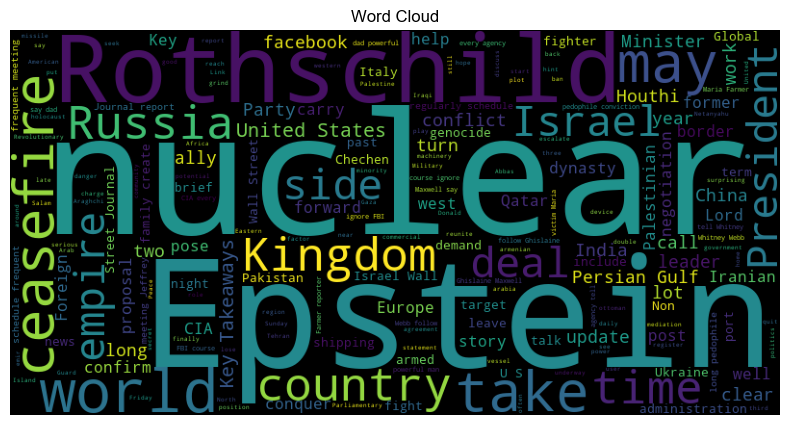

In [ ]:
text_for_wc = " ".join(token2_df["lemma"].astype(str))

wc = WordCloud(width=800, height=400).generate(text_for_wc)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

### 4.4.5 小結

本節透過 Stanford CoreNLP 進行斷詞與詞形還原，
並使用 NLTK 移除常見停用詞與自訂無意義詞
（如 us、said、war 等），以提升文字分析的準確性。

從文字雲可以觀察到：




1.   **主題集中在國際政治與衝突**（middle、east、israel、russia）
2.   **以國家與政策行為為核心**（country、government、deal）表示內容多在描述國家之間的互動與決策

3.   **偏新聞敘事風格**（say、take、call）代表多在描述事件與發言

## 4.5 CoreNLP 標註

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib


# 設定中文字型（放前面OK）
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
matplotlib.rcParams['axes.unicode_minus'] = False  # 避免負號變亂碼

# 讀取資料
file_path = "reddit_results.xlsx"
sent_df = pd.read_excel(file_path)

# 確認欄位名稱
print(sent_df.columns)

# 建立 id
sent_df = sent_df.reset_index().rename(columns={"index": "id"})

Index(['TITLE', 'DATE', 'LINK', 'CONTENT', 'SENTENCE'], dtype='object')


執行NLP解析（一樣是Stanford CoreNLP）
把每一筆資料的「文字」拆成可以分析的結構化資料，取得：

1.   分詞（token）
2.   詞形還原（lemma）
3.   詞性（POS）
4.   命名實體（NER）
5.   情緒（sentiment）

In [ ]:
def get_nlp_result(df, text_col, id_col):

    token_list = []
    senti_list = []
    mention_list = []

    for index, row in df.iterrows():
        try:
            document = client.annotate(str(row[text_col])[:500])

            for sent in document.sentence:
                sentence_text = ""

                for t in sent.token:
                    sentence_text += " " + t.word

                    token_list.append([
                        row[id_col],
                        t.word,
                        t.lemma,
                        t.pos,
                        t.ner
                    ])

                senti_list.append([
                    row[id_col],
                    sentence_text,
                    sent.sentiment
                ])

                for mention in sent.mentions:
                    mention_list.append([
                        row[id_col],
                        mention.entityMentionText,
                        mention.ner
                    ])

        except Exception as e:
            print("Error:", e)   # 🔥不要吃掉錯誤
            continue

    token_table = pd.DataFrame(token_list, columns=[id_col,'word','lemma','pos','ner'])
    senti_table = pd.DataFrame(senti_list, columns=[id_col,'sentence','sentiment'])
    mention_table = pd.DataFrame(mention_list, columns=[id_col,'mention','ner'])

    return token_table, senti_table, mention_table

In [ ]:
sample_df = sent_df.head(100)

token_df, senti_df, mention_df = get_nlp_result(
    sample_df,
    text_col="SENTENCE",
    id_col="id"
)

2026-03-28 22:47:47 INFO: Starting server with command: java -Xmx4G -cp ./stanza_corenlp/* edu.stanford.nlp.pipeline.StanfordCoreNLPServer -port 9999 -timeout 30000000 -threads 5 -maxCharLength 100000 -quiet True -serverProperties corenlp_server-081b050b0ad24120.props -annotators tokenize,ssplit,pos,lemma,ner,entitymentions,parse,sentiment -preload -outputFormat serialized


token_df 做文字雲、詞頻分析、POS 分析

In [ ]:
# 字詞標註dataframe # 文章id, 字詞, 詞性還原, 詞性, 實體
token_df.head(10)

,id,word,lemma,pos,ner
0,0,"""","""",``,O
1,0,how,how,WRB,O
2,0,israel,israel,NNP,COUNTRY
3,0,helped,help,VBD,O
4,0,create,create,VB,O
5,0,hamas,hama,NNS,O
6,0,"""","""",'',O
7,0,"""","""",``,O
8,0,israel,israel,NN,COUNTRY
9,0,and,and,CC,O


senti_df 做情緒分析（正負面）、時間趨勢分析

In [ ]:
# 情緒分析dataframe # 文章id, 句子, 情緒
senti_df.head()

,id,sentence,sentiment
0,0,""" how israel helped create hamas "" "" israel a...",Negative
1,1,"sir iain duncan smith mp , former leader of t...",Negative
2,1,sir iain has argued that support for ukraine ...,Negative
3,1,sir iain has also,Neutral
4,2,what if the same cartel that did epstein isla...,Positive


mention_df 分析「誰最常被提到」、國家 / 人物關聯分析

In [ ]:
# 實體標註 dataframe # 文章id, 字詞, 實體
mention_df.head()

,id,mention,ner
0,0,israel,COUNTRY
1,0,israel,COUNTRY
2,0,u.s.,COUNTRY
3,0,al qaeda,IDEOLOGY
4,0,israel,COUNTRY


In [ ]:
# 檢查筆數是否一致
print(f"total posts numbers: {len(token_df['id'].unique())}")
print(f"posts sentiment: {len(senti_df['id'].unique())}")
print(f"posts have NER: {len(mention_df['id'].unique())}")

total posts numbers: 100
posts sentiment: 100
posts have NER: 100


In [ ]:
# 儲存結果
token_df.to_csv('tokens_tp.csv', encoding = 'utf-8', index = False)
senti_df.to_csv('sentiment_tp.csv', encoding = 'utf-8', index = False)
mention_df.to_csv('mention_tp.csv', encoding = 'utf-8', index = False)

## 4.6 探索分析 - NER

In [ ]:
# 讀取已經執行完畢的結果
tokens = pd.read_csv('tokens_tp.csv')
mention = pd.read_csv('mention_tp.csv')
sentiment = pd.read_csv('sentiment_tp.csv')

### 4.6.1 NER 種類分析
查看這個文集辨識出哪一些實體種類

In [ ]:
# 查看辨識出哪幾種NER
tokens['ner'].unique()

array(['O', 'COUNTRY', 'IDEOLOGY', 'NUMBER', 'NATIONALITY', 'PERSON',
       'TITLE', 'ORGANIZATION', 'MISC', 'CAUSE_OF_DEATH', 'DATE', 'TIME',
       'SET', 'DURATION', 'ORDINAL', 'RELIGION', 'CRIMINAL_CHARGE',
       'LOCATION', 'STATE_OR_PROVINCE', 'MONEY', 'CITY'], dtype=object)

In [ ]:
# 'O' 代表 other，看看除了other，有幾個字有被標出 entity
len(tokens.loc[tokens['ner'] != 'O']['word'].unique()) # 417個字有被標出entity

315

In [ ]:
# 查看辨識出哪幾種NER
mention['ner'].unique()

array(['COUNTRY', 'IDEOLOGY', 'NUMBER', 'NATIONALITY', 'PERSON', 'TITLE',
       'ORGANIZATION', 'MISC', 'CAUSE_OF_DEATH', 'DATE', 'TIME', 'SET',
       'DURATION', 'ORDINAL', 'RELIGION', 'CRIMINAL_CHARGE', 'LOCATION',
       'STATE_OR_PROVINCE', 'MONEY', 'CITY'], dtype=object)

可以發現以字為單位的`tokens`中的 NER 標記，會有`O`類別的標記，代表非NER的字詞，而`mention`則是以完整的名詞為單位，為了方便分析，我們使用`mention`中的結果進行統計

In [ ]:
# 進行類別統計
ner_count = mention.groupby(['ner'])['ner'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(10)
ner_count

,ner,count
2,COUNTRY,243
11,NUMBER,139
4,DATE,104
0,CAUSE_OF_DEATH,62
10,NATIONALITY,48
19,TITLE,46
14,PERSON,45
5,DURATION,25
6,IDEOLOGY,14
12,ORDINAL,10


/var/folders/j3/241sng5j19dfmfvy_zm1b1nm0000gn/T/ipykernel_1737/972383025.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


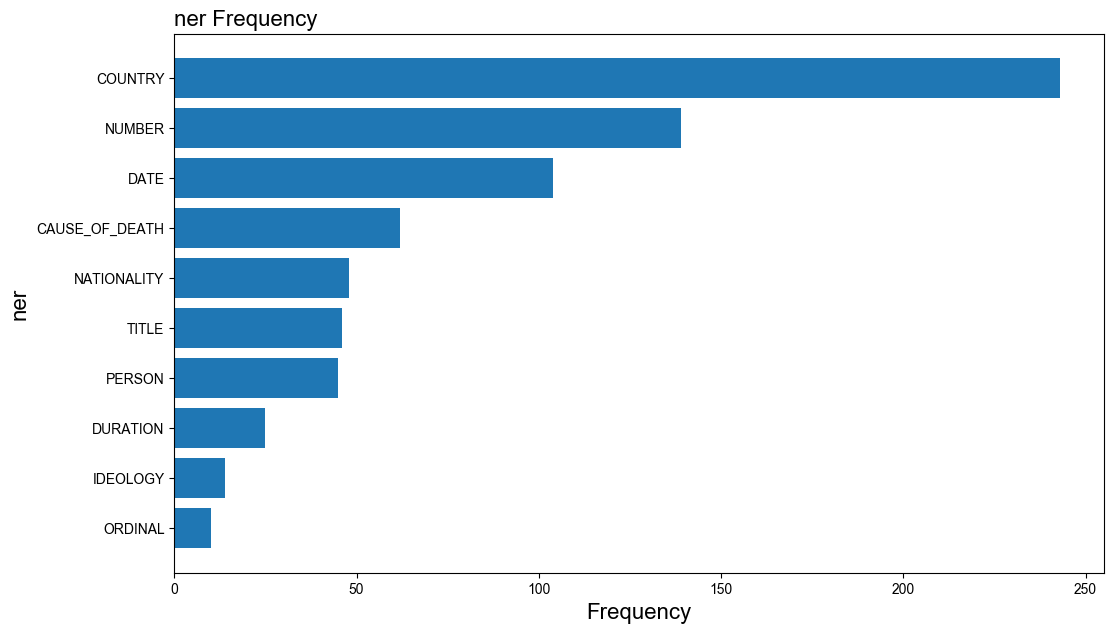

In [ ]:
ner = ner_count['ner']
count = ner_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(ner, count)
ax.invert_yaxis()
ax.set_title('ner Frequency',loc ='left', size = 16)
ax.set_ylabel('ner', size = 16)
ax.set_xlabel('Frequency', size = 16)
fig.show()

因為本次分析文本為戰爭，所以國家名稱出現的頻率會比其他實體高非常多。

為了正確計算詞頻，將字詞轉小寫存新欄位

In [ ]:
mention['word_lower'] = mention['mention'].str.lower()
mention.tail()

,id,mention,ner,word_lower
787,99,hacker,TITLE,hacker
788,99,israeli,NATIONALITY,israeli
789,99,u.s.,COUNTRY,u.s.
790,99,404,NUMBER,404
791,99,now,DATE,now


### 4.6.2 涉及到的國家
+ 透過coreNLP中的NER解析出在sample_df中所涉及到的地點(LOCATION)

In [ ]:
# 篩選ner為country的資料
location = mention.loc[mention['ner'] == 'COUNTRY']

# 計算每個地點提到的次數，選出前8個
location_count = location[['word_lower']].groupby(['word_lower'])['word_lower'].count().reset_index(name='count')
location_count = location_count.sort_values(['count'], ascending=False).head(8)
location_count

,word_lower,count
21,israel,46
17,india,28
29,pakistan,27
18,iran,21
45,u.s.,15
8,china,10
33,russia,9
50,usa,5


Text(0.5, 0, 'Word Frequency')

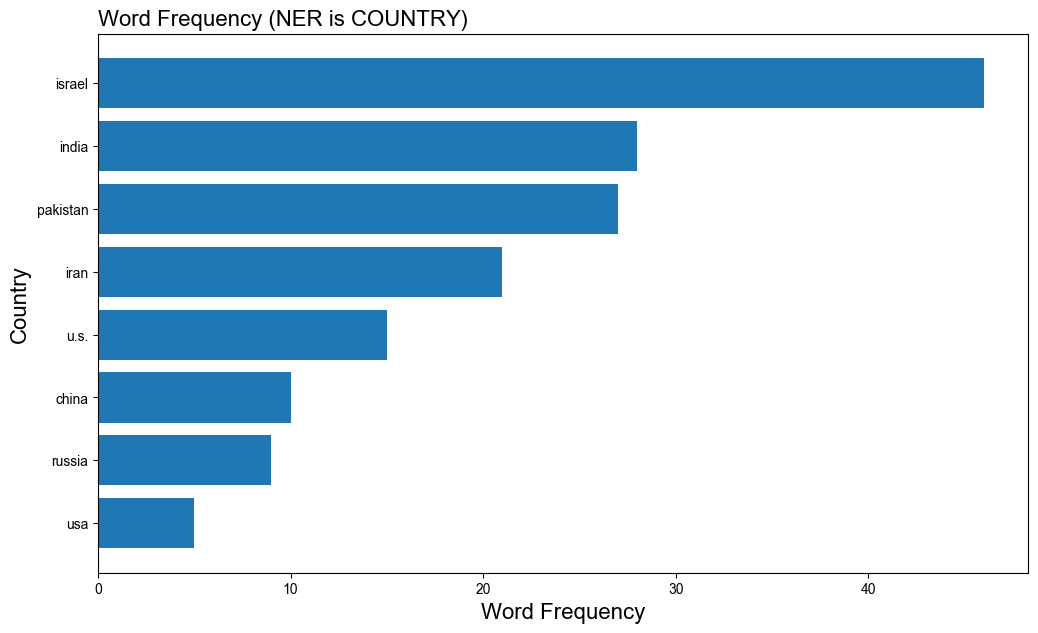

In [ ]:
word = location_count['word_lower']
count = location_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is COUNTRY)',loc ='left', size = 16)
ax.set_ylabel('Country', size = 16)
ax.set_xlabel('Word Frequency', size = 16)
# fig.show()

In [ ]:
# 查看特定關鍵字的貼文內容
# 查詢關鍵字
keyword_list = ['pakistan']

# 1️⃣ 找有出現關鍵字的 id
ids = token_df[
    token_df['lemma'].str.contains('|'.join(keyword_list), case=False, na=False)
]['id'].unique()

# 2️⃣ 回到sample_df
df_result = sample_df[sample_df['id'].isin(ids)]

# 3️⃣ 印結果
print(f"{' '.join(keyword_list)}：{df_result.shape[0]} 篇相關文章")

df_result.head()

pakistan：13 篇相關文章


,id,TITLE,DATE,LINK,CONTENT,SENTENCE
10,10,Regarding the open role of turkiye &amp; azerb...,2025-05-14,https://i.redd.it/x712mowc1r0f1.png,Why has India not yet recognised the Armenian ...,why has india not yet recognised the armenian ...
16,16,Learned some horrific stuff from India's past ...,2025-05-12,https://www.reddit.com/r/OfficialIndia/comment...,You asked:\n\nDid russia save india during the...,you asked: did russia save india during the 19...
17,17,Is China actually allied with Pakistan? Does t...,2025-05-12,https://www.reddit.com/r/TrueAnon/comments/1kk...,In western geopolitical discourse you often se...,in western geopolitical discourse you often se...
18,18,Ceasefire analysis (one of the logical one),2025-05-12,https://twitter.com/ImtiazMadmood/status/19216...,\nDecoding the Trump-mediated ceasefire:\n\n- ...,decoding the trump-mediated ceasefire: - by ka...
22,22,"A wake-up call for all Indian startups, we mus...",2025-05-11,https://www.reddit.com/r/indianstartups/commen...,These past few days have made me contemplate m...,these past few days have made me contemplate m...


### 4.6.3 涉及到的人物
+ 我們可以透過coreNLP中的NER解析所涉及到的人物(PERSON)
+ 有些人稱代名詞(personal pronoun) 像 her或 his， 在 `mention` 裡屬於 `PERSON` ，但應該更接近於 `token` 裡面的 `O`分類，在計算詞頻的時候把他們先過濾掉

In [ ]:
# 查看 he 的 NER 分類
keyword_list = ['he']
print("for ner:", tokens.loc[tokens['word'] == 'he'].ner.unique())
print("for entityMention:", mention.loc[mention['word_lower'] == 'he'].ner.unique())

for ner: ['O']
for entityMention: ['PERSON']


In [ ]:
peo = mention.loc[mention['ner'] == 'PERSON']

# 手動移除coreNLP分不好的字詞
peo['word_lower'] = peo['mention'].str.lower()
remove_l = ['her','his','he','she','him']
peo = peo[~peo.word_lower.isin(remove_l)]
peo_count = (
    peo.groupby('word_lower')
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(10)
)

peo_count

/var/folders/j3/241sng5j19dfmfvy_zm1b1nm0000gn/T/ipykernel_1737/2784487448.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peo['word_lower'] = peo['mention'].str.lower()


,word_lower,count
4,jeffrey epstein,5
0,biden,1
1,donald trump,1
2,hegseth,1
3,iain duncan smith,1
5,marco rubio,1
6,robert kocharyan,1


Text(0.5, 0, 'Word Frequency')

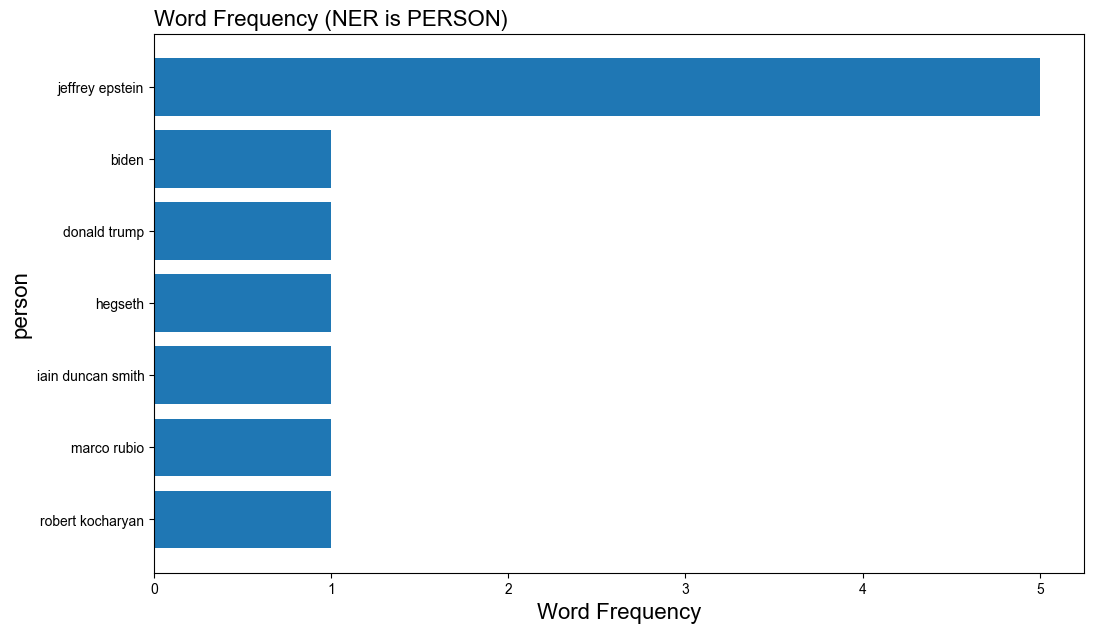

In [ ]:
word = peo_count['word_lower']
count = peo_count['count']

fig, ax = plt.subplots(figsize =(12, 7))
ax.barh(word, count)
ax.invert_yaxis()
ax.set_title('Word Frequency (NER is PERSON)',loc ='left', size = 16)
ax.set_ylabel('person', size = 16)
ax.set_xlabel('Word Frequency', size = 16)
# fig.show()

+ 不知道是不是撈新聞資料的關係，把其他新聞也撈進去，jeffrey epstein出現的頻率很高

In [ ]:
keyword_list = ['jeffrey', 'epstein']

# 1️⃣ 找同時包含兩個關鍵字的文章
ids = token_df[
    token_df['lemma'].str.lower().isin(keyword_list)
].groupby('id').filter(
    lambda x: set(keyword_list).issubset(set(x['lemma'].str.lower()))
)['id'].unique()

# 2️⃣ 回到原文
df_result = sample_df[sample_df['id'].isin(ids)]

print(f"{' '.join(keyword_list)}：{df_result.shape[0]} 篇相關文章")

df_result[['SENTENCE']].head()

jeffrey epstein：5 篇相關文章


,SENTENCE
2,what if the same cartel that did epstein islan...
5,"""lord rothschild: my family created israel"" th..."
13,"""lord rothschild: my family created israel"" th..."
44,"""lord rothschild: my family created israel"" th..."
74,"""lord rothschild: my family created israel"" th..."


## 4.7 探索分析 - Sentiment
將經過coreNLP處理後的文集，進行情緒分析

In [ ]:
# 讀取已經執行完畢的結果
sentiment = pd.read_csv("sentiment_tp.csv")
sentiment.head(5)

,id,sentence,sentiment
0,0,""" how israel helped create hamas "" "" israel a...",Negative
1,1,"sir iain duncan smith mp , former leader of t...",Negative
2,1,sir iain has argued that support for ukraine ...,Negative
3,1,sir iain has also,Neutral
4,2,what if the same cartel that did epstein isla...,Positive


In [ ]:
# 看有哪些情緒
sentiment['sentiment'].unique()

array(['Negative', 'Neutral', 'Positive', 'Very positive'], dtype=object)

In [ ]:
# 看一下各情緒的分布
sentiment.groupby('sentiment')['sentiment'].agg(['count'])

,count
sentiment,
Negative,183
Neutral,176
Positive,71
Very positive,1


In [ ]:
# 將情緒轉為分數
def label_sentiment(row):
    if row['sentiment'] == "Very positive" :
        return 2
    if row['sentiment'] == "Positive" :
        return 1
    if row['sentiment'] == "Neutral" :
        return 0
    if row['sentiment'] == "Negative" :
        return -1
    if row['sentiment'] == "Very negative" :
        return -2

In [ ]:
sentiment['sentimentValue'] = sentiment.apply(lambda row: label_sentiment(row), axis=1)
sentiment.head()

,id,sentence,sentiment,sentimentValue
0,0,""" how israel helped create hamas "" "" israel a...",Negative,-1
1,1,"sir iain duncan smith mp , former leader of t...",Negative,-1
2,1,sir iain has argued that support for ukraine ...,Negative,-1
3,1,sir iain has also,Neutral,0
4,2,what if the same cartel that did epstein isla...,Positive,1


**平均情緒分數趨勢**
*   將句子層級的情緒分數進行分組平均，轉換為文章層級的整體情緒指標，以利後續比較與分析。

In [ ]:
print(sample_df.columns)

Index(['id', 'TITLE', 'DATE', 'LINK', 'CONTENT', 'SENTENCE'], dtype='object')


In [ ]:
sentiment_count = (
    sentiment.groupby('id')['sentimentValue']
    .mean()
    .reset_index()
)

sentiment_count.head()

,id,sentimentValue
0,0,-1.000000
1,1,-0.666667
2,2,1.000000
3,3,0.333333
4,4,0.000000


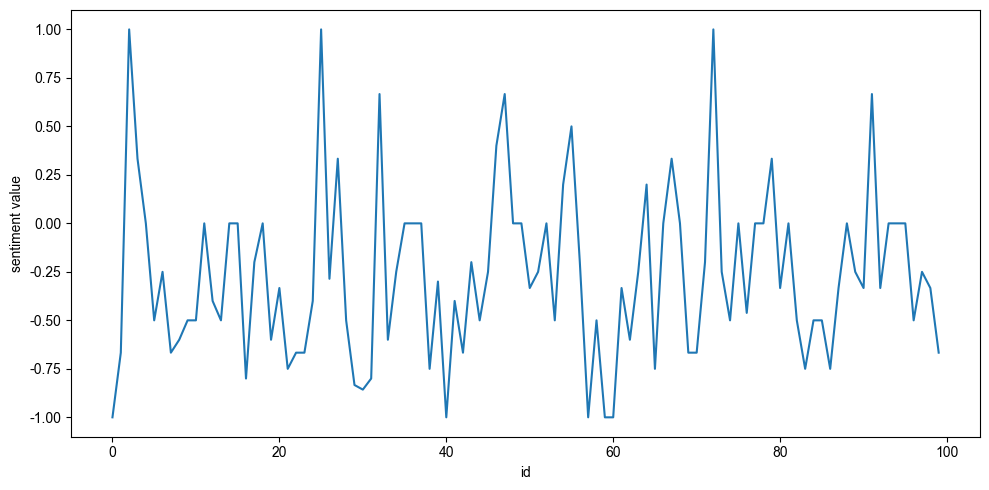

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    sentiment_count['id'],
    sentiment_count['sentimentValue'],
    linestyle='solid'
)

plt.xlabel('id')  # x軸
plt.ylabel('sentiment value')  # y軸

plt.tight_layout()
plt.show()


可以看出在美伊戰爭議題中，大部分的情緒偏負面。

### 4.7.1 正面詞彙探索
把正面章節挑出來，看看他們都用甚麼詞

In [ ]:
# 把 token 的字詞降大小寫
tokens['lemma_lower'] = tokens['lemma'].str.lower()

In [ ]:
# 挑出正面句子
positive = sentiment[sentiment['sentiment'].isin(['Positive'])]

# 合併 token（用 id）
positive_words = pd.merge(
    positive,
    token_df,
    on='id',
    how='left'
)

positive_words.head()

,id,sentence,sentiment,sentimentValue,word,lemma,pos,ner
0,2,what if the same cartel that did epstein isla...,Positive,1,what,what,WP,O
1,2,what if the same cartel that did epstein isla...,Positive,1,if,if,IN,O
2,2,what if the same cartel that did epstein isla...,Positive,1,the,the,DT,O
3,2,what if the same cartel that did epstein isla...,Positive,1,same,same,JJ,O
4,2,what if the same cartel that did epstein isla...,Positive,1,cartel,cartel,NN,O


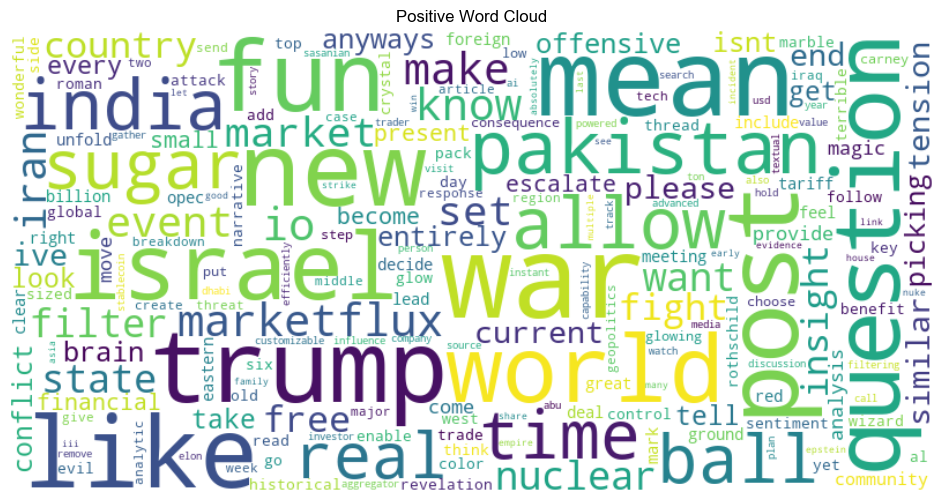

In [ ]:
positive_words['lemma_lower'] = positive_words['lemma'].astype(str).str.lower()

# 移除空值
positive_words = positive_words[
    positive_words['lemma_lower'].notna()
]

# 移除 stop words
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
stop_words.update([
    "could", "would", "might", "may", "must",
    "_", "nan", "u", "s","one"
])

# 文字雲
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(positive_words['lemma_lower'])

wordcloud = WordCloud(
    stopwords=stop_words,
    max_font_size=100,
    width=800,
    height=400,
    background_color="white",
    collocations=False   # 🔥避免 weird 組合詞
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Word Cloud")
plt.show()

#### 4.7.1.2 探索結果
相較於全部資料一起做的文字雲

1.   出現比較多與「行動、發展」相關的詞彙(run、make、set、provide、lead) 代表正面情緒多來自於政策推動、行動執行、發展進程

2.   帶有經濟與市場語意（market、trade、financial）
代表正向內容常與經濟合作、市場發展有關

3.   正面情緒並不代表「輕鬆或娛樂內容」而是比較多政策進展、國際合作、局勢改善的內容

### 4.7.2 負面詞彙探索

In [ ]:
# 挑出句子
negative = sentiment[sentiment['sentiment'].isin(['Negative'])]

# 合併 token（用 id）
negative_words = pd.merge(
    negative,
    token_df,
    on='id',
    how='left'
)

negative_words.head()

,id,sentence,sentiment,sentimentValue,word,lemma,pos,ner
0,0,""" how israel helped create hamas "" "" israel a...",Negative,-1,"""","""",``,O
1,0,""" how israel helped create hamas "" "" israel a...",Negative,-1,how,how,WRB,O
2,0,""" how israel helped create hamas "" "" israel a...",Negative,-1,israel,israel,NNP,COUNTRY
3,0,""" how israel helped create hamas "" "" israel a...",Negative,-1,helped,help,VBD,O
4,0,""" how israel helped create hamas "" "" israel a...",Negative,-1,create,create,VB,O


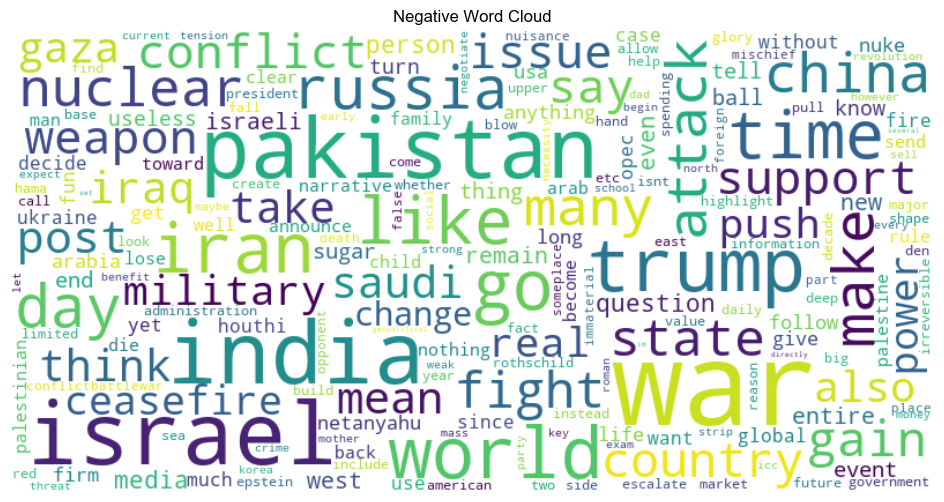

In [ ]:
negative_words['lemma_lower'] = negative_words['lemma'].astype(str).str.lower()

# 移除空值
negative_words = negative_words[
    negative_words['lemma_lower'].notna()
]

# 移除 stop words
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
stop_words.update([
    "could", "would", "might", "may", "must",
    "_", "nan", "u", "s","one"
])

# 文字雲
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(negative_words['lemma_lower'])

wordcloud = WordCloud(
    stopwords=stop_words,
    max_font_size=100,
    width=800,
    height=400,
    background_color="white",
    collocations=False   # 🔥避免 weird 組合詞
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Word Cloud")
plt.show()

正負面文字雲相比之下，會發現國家名稱多出現於負面場景。

#### 4.7.1.2 探索結果
相較於全部資料一起做的文字雲

1.   出現比較多與「行動、發展」相關的詞彙(run、make、set、provide、lead) 代表正面情緒多來自於政策推動、行動執行、發展進程

2.   帶有經濟與市場語意（market、trade、financial）
代表正向內容常與經濟合作、市場發展有關

3.   正面情緒並不代表「輕鬆或娛樂內容」而是比較多政策進展、國際合作、局勢改善的內容

In [ ]:
# 最後再把背景的client關掉
# client.stop() 是用來關閉 CoreNLP 的背景 server
  # 若不關閉，會持續占用記憶體，容易造成電腦變慢、風扇變大聲
  # Port可能被占用，導致下次無法正常啟動
  # 可能出現「port already in use」錯誤
  # Notebook 關掉後，背景程序仍可能持續運行
  # 多次執行會重複開 server，增加當機風險

#time.sleep(5) 是為了讓server有時間完全關閉，避免資源尚未釋放就執行下一步

client.stop()
time.sleep(5)

# 5. 結論


1. 議題核心與政治導向  
透過文字雲與詞頻分析可觀察到，美國（USA）與以色列（Israel）為討論中最核心的實體，顯示社群關注焦點高度集中於兩國在衝突中的角色與行動。關鍵詞 Trump（川普）在分析中佔有顯著比例，反映使用者高度關注其過去對伊政策的影響，以及未來可能回歸後對國際局勢的潛在衝擊。相關討論亦延伸至印度、巴基斯坦、中國與俄羅斯等國的立場，顯示社群普遍認為此衝突具有全球性影響，並可能引發地緣政治的連鎖反應。

2. 情緒表現的時間與空間特性  
從時間序列觀察，每日正負向情緒比例多落在0.4至0.6之間，顯示社群情緒會隨著事件發展而產生波動，而非固定不變。儘管LIWC分析中正向詞彙如support與hope的出現頻率略高，但多數來自對和平或支持的期待。整體而言，從情緒比例與分數趨勢來看，討論仍以負面情緒為主，例如戰爭、攻擊與威脅等語彙。此外，文本中出現Mossad（摩薩德）與Rothschild（羅斯柴爾德）等詞彙，顯示部分討論已延伸至情報活動、權力結構與陰謀論等較深層議題，反映社群對事件背後機制的關注。

3. 技術實踐之成效  
整合字典法LIWC與CoreNLP語法分析工具。LIWC主要用於進行情緒詞彙的快速統計，而CoreNLP則提供語法分析、五級情緒分類以及命名實體辨識功能，可辨識國家與人物等實體類型。兩者在分析上具有互補性，LIWC能有效掌握情緒詞彙的分布情況，CoreNLP則能提升語意理解與實體辨識的精細度，整體提升分析結果的準確性。

總結  
結果顯示，Reddit社群在面對美伊戰爭議題時，呈現出高度政治敏感性與負面情緒主導的特徵。透過情緒分數折線圖與文字雲等視覺化分析工具，可以清楚觀察到社群討論從地緣政治層面的戰略思考，延伸至對軍事衝突與不安全感的關注，呈現出多層次且複雜的討論結構。


# 6. 執行過程中的障礙與解決方法

### 1. Reddit API 存取限制問題

**問題：**  
原先依照建議使用 Reddit Data API key 進行資料查詢，但在實際操作過程中，發現金鑰無法順利產出。可能源於 Reddit 已停用或限制部分 OAuth API 的存取權限，導致原有方式無法正常取得授權。
[Reddit 砍掉了自助式 API 金鑰：你自動化整合 Reddit 的選項](https://www.reddit.com/r/n8n/comments/1r17pdr/reddit_killed_selfservice_api_keys_your_options/?tl=zh-hant)

**解決方法：**  
改用 Pullpush 提供的 Reddit 搜尋 API，成功取得所需資料，並提升資料收集的可行性與完整度。



### 2. Pullpush API 穩定性問題

**問題：**  
在資料蒐集過程中，Pullpush API 曾出現一段時間的不穩定狀況（如回應失敗或資料不完整），影響分析流程的連續性。

**解決方法：**  
若遇到APT失效的情況時，將改為使用先前已成功匯出並保存的資料結果進行後續分析，以確保研究流程不中斷，同時提升資料使用的穩定性。



### 3. CoreNLP 執行效能問題

**問題：**  
在執行 CoreNLP 進行語意與情緒分析時，由於資料量較大，單次運算時間過長（約需 3 小時以上），甚至可能出現執行失敗的情況。

**解決方法：**  
調整分析策略，改為擷取前 100 筆資料進行分析，在兼顧運算效率與分析代表性的前提下，大幅縮短處理時間並提升成功率。